# PhaseID → FAIDR target files

This notebook builds **annotation files** for `iva_FAIDR_no_cv.R` from PhaseID mass-spec Excel files.

**Goal:** for each experiment (SP1, TAF, EWS) and each sheet (`enrich` / `deplete`), create a tab-separated file with:
- `idr_name` — row ID (from `HUMAN_ES` or from FS feature file)
- `NAME` — UniProt accession (parsed from `idr_name`)
- `enrich` or `deplete` — `1` if that protein was in the PhaseID list, else `0`

Output format matches `HIGH_AUC_PPV_FILTERED_FUNCTIONS/GO0005730_nucleolus.txt`.

## Setup: paths and libraries

In [6]:
from pathlib import Path

import pandas as pd

# Project root (folder where this notebook lives)
PROJECT_ROOT = Path(".").resolve()

PHASEID_DIR = PROJECT_ROOT / "data_from_collaborators" / "PhaseID"
EF_PATH = PROJECT_ROOT / "HUMAN_ES.txt"
FS_PATH = PROJECT_ROOT / "FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv"
OUTPUT_DIR = PROJECT_ROOT / "HIGH_AUC_PPV_FILTERED_FUNCTIONS"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output folder:", OUTPUT_DIR)

Project root: /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR
Output folder: /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/HIGH_AUC_PPV_FILTERED_FUNCTIONS


## Step 1 — Load Excel files and build Accession lists

Each Excel file has two sheets we need: **`deplete`** and **`enrich`**.
We read only the **`Accession`** column (UniProt IDs like `P02794`).

List names follow the pattern `{sample}_{sheet}`, e.g. `SP1_enrich`, `TAF_deplete`.

In [7]:
# Map: short sample name -> Excel file name
PHASEID_FILES = {
    "SP1": "QH_8523101124_sp1_noB1RB4_EC_latelog_pvalue_log2_knnimp_real_accession_uniqconf_blkoverlap_extracted.xlsx",
    "TAF": "QH_73023101124_TAF_EC_latelog_pvalue_log2_knnimp_real_accession_uniqconf_blkoverlap_extracted.xlsx",
    "EWS": "QH_72823730241022_EWS_EC_latelog_pvalue_log2ratio2_knnimp_real_accession_uniqconf_blkoverlap_extracted.xlsx",
}

SHEETS = ["deplete", "enrich"]

# We will store Python sets of accession strings
accession_lists = {}

for sample, filename in PHASEID_FILES.items():
    excel_path = PHASEID_DIR / filename
    for sheet in SHEETS:
        list_name = f"{sample}_{sheet}"

        df = pd.read_excel(excel_path, sheet_name=sheet, usecols=["Accession"])
        # Drop empty rows; convert to string; remove duplicates
        accessions = (
            df["Accession"]
            .dropna()
            .astype(str)
            .str.strip()
            .unique()
            .tolist()
        )
        accession_lists[list_name] = set(accessions)
        print(f"Loaded {list_name}: {len(accessions)} accessions from {excel_path.name} [{sheet}]")

Loaded SP1_deplete: 54 accessions from QH_8523101124_sp1_noB1RB4_EC_latelog_pvalue_log2_knnimp_real_accession_uniqconf_blkoverlap_extracted.xlsx [deplete]
Loaded SP1_enrich: 120 accessions from QH_8523101124_sp1_noB1RB4_EC_latelog_pvalue_log2_knnimp_real_accession_uniqconf_blkoverlap_extracted.xlsx [enrich]
Loaded TAF_deplete: 304 accessions from QH_73023101124_TAF_EC_latelog_pvalue_log2_knnimp_real_accession_uniqconf_blkoverlap_extracted.xlsx [deplete]
Loaded TAF_enrich: 348 accessions from QH_73023101124_TAF_EC_latelog_pvalue_log2_knnimp_real_accession_uniqconf_blkoverlap_extracted.xlsx [enrich]
Loaded EWS_deplete: 181 accessions from QH_72823730241022_EWS_EC_latelog_pvalue_log2ratio2_knnimp_real_accession_uniqconf_blkoverlap_extracted.xlsx [deplete]
Loaded EWS_enrich: 204 accessions from QH_72823730241022_EWS_EC_latelog_pvalue_log2ratio2_knnimp_real_accession_uniqconf_blkoverlap_extracted.xlsx [enrich]


### List lengths

These numbers are **unique proteins** in each PhaseID list (not IDR rows).

In [8]:
print("\n--- List lengths ---")
for name in sorted(accession_lists.keys()):
    print(f"{name}: {len(accession_lists[name])}")


--- List lengths ---
EWS_deplete: 181
EWS_enrich: 204
SP1_deplete: 54
SP1_enrich: 120
TAF_deplete: 304
TAF_enrich: 348


## Step 2a — `HUMAN_ES.txt`: `idr_name` → `NAME`, save target files

FAIDR uses one row per **IDR**. Example `idr_name`: `Q5VUJ6_IDR_1_54` → `NAME` = `Q5VUJ6` (text before the first `_`).

For each PhaseID list (e.g. `SP1_enrich`):
1. Third column is named like the Excel sheet: `enrich` or `deplete`
2. Value `1` if `NAME` is in that Accession list, else `0`
3. Save to `HIGH_AUC_PPV_FILTERED_FUNCTIONS/SP1_enrich_EF.txt` (suffix `_EF`)

If one protein has several IDRs, all rows with the same `NAME` get the same label.

In [9]:
human_es = pd.read_csv(EF_PATH, sep="\t", usecols=["idr_name"])
human_es["NAME"] = human_es["idr_name"].str.split("_").str[0]

print(f"IDR rows in HUMAN_ES: {len(human_es)}")
print(f"Unique NAME in HUMAN_ES: {human_es['NAME'].nunique()}")

saved_files_ef = []
for list_name, accession_set in accession_lists.items():
    sheet_label = list_name.split("_", 1)[1]

    out_df = human_es.copy()
    out_df[sheet_label] = out_df["NAME"].isin(accession_set).astype(int)

    out_path = OUTPUT_DIR / f"{list_name}_EF.txt"
    out_df.to_csv(out_path, sep="\t", index=False)
    saved_files_ef.append(out_path)

    print(f"Saved {out_path.name}: {out_df[sheet_label].sum()} IDR rows labeled 1 ({sheet_label})")

print(f"\nTotal EF files written: {len(saved_files_ef)}")
print(human_es.head())

IDR rows in HUMAN_ES: 19032
Unique NAME in HUMAN_ES: 11640
Saved SP1_deplete_EF.txt: 86 IDR rows labeled 1 (deplete)
Saved SP1_enrich_EF.txt: 165 IDR rows labeled 1 (enrich)
Saved TAF_deplete_EF.txt: 627 IDR rows labeled 1 (deplete)
Saved TAF_enrich_EF.txt: 352 IDR rows labeled 1 (enrich)
Saved EWS_deplete_EF.txt: 351 IDR rows labeled 1 (deplete)
Saved EWS_enrich_EF.txt: 289 IDR rows labeled 1 (enrich)

Total EF files written: 6
             idr_name    NAME
0     Q5VUJ6_IDR_1_54  Q5VUJ6
1  Q8TD19_IDR_825_961  Q8TD19
2  Q9H425_IDR_129_306  Q9H425
3  Q8NBI5_IDR_214_268  Q8NBI5
4  P36941_IDR_369_411  P36941


## Step 2b — FS feature file: `idr_name` + `NAME`, save target files

Feature file: `FS_PATH` (`FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv`, tab-separated)

→ `idr_name` = `>sp|P19532|TFE3_HUMAN.diso:2`  
→ `NAME` = text between `|` → `P19532`

Output suffix **`_FS`** (e.g. `SP1_enrich_FS.txt`).

In [10]:
fs = pd.read_csv(FS_PATH, sep="\t", usecols=["idr_name"])
fs = fs.dropna(subset=["idr_name"])

fs["NAME"] = fs["idr_name"].str.extract(r"\|([^|]+)\|")[0]
fs = fs.dropna(subset=["NAME"])

print(f"Rows in FS file: {len(fs)}")
print(f"Unique NAME in FS: {fs['NAME'].nunique()}")

saved_files_fs = []
for list_name, accession_set in accession_lists.items():
    sheet_label = list_name.split("_", 1)[1]

    out_df = fs[["idr_name", "NAME"]].copy()
    out_df[sheet_label] = out_df["NAME"].isin(accession_set).astype(int)

    out_path = OUTPUT_DIR / f"{list_name}_FS.txt"
    out_df.to_csv(out_path, sep="\t", index=False)
    saved_files_fs.append(out_path)

    print(f"Saved {out_path.name}: {out_df[sheet_label].sum()} rows labeled 1 ({sheet_label})")

print(f"\nTotal FS files written: {len(saved_files_fs)}")
print(out_df.head())

Rows in FS file: 21252
Unique NAME in FS: 13044
Saved SP1_deplete_FS.txt: 93 rows labeled 1 (deplete)
Saved SP1_enrich_FS.txt: 189 rows labeled 1 (enrich)
Saved TAF_deplete_FS.txt: 665 rows labeled 1 (deplete)
Saved TAF_enrich_FS.txt: 361 rows labeled 1 (enrich)
Saved EWS_deplete_FS.txt: 368 rows labeled 1 (deplete)
Saved EWS_enrich_FS.txt: 293 rows labeled 1 (enrich)

Total FS files written: 6
                        idr_name    NAME  enrich
1   >sp|P19532|TFE3_HUMAN.diso:2  P19532       0
2  >sp|Q5T5Y3|CAMP1_HUMAN.diso:6  Q5T5Y3       0
3  >sp|O43525|KCNQ3_HUMAN.diso:3  O43525       0
4  >sp|Q8N9Y4|F181A_HUMAN.diso:4  Q8N9Y4       0
5   >sp|Q14680|MELK_HUMAN.diso:2  Q14680       0


## Step 3 — Check saved target files (`_EF` and `_FS`)

For each output file (Step 2a and Step 2b):

1. **Unique NAME with label 1**
2. **Same label for every row with the same NAME?** — must be `True`

If any `NAME` has both `0` and `1`, something went wrong.

In [11]:
qc_rows = []

target_files = [
    (list_name, OUTPUT_DIR / f"{list_name}_EF.txt", "EF")
    for list_name in accession_lists
] + [
    (list_name, OUTPUT_DIR / f"{list_name}_FS.txt", "FS")
    for list_name in accession_lists
]

for list_name, path, source in target_files:
    sheet_label = list_name.split("_", 1)[1]
    df = pd.read_csv(path, sep="\t")

    pos = df[df[sheet_label] == 1]
    n_unique_name_with_1 = pos["NAME"].nunique()

    # Each NAME should have only one label value across all its IDR rows
    labels_per_name = df.groupby("NAME")[sheet_label].nunique()
    n_name_mixed = int((labels_per_name > 1).sum())
    same_label_per_name = n_name_mixed == 0

    qc_rows.append({
        "file": path.name,
        "source": source,
        "n_unique_NAME_with_1": n_unique_name_with_1,
        "n_rows_with_1": int(df[sheet_label].sum()),
        "same_label_for_all_NAME": same_label_per_name,
        "NAME_with_mixed_0_and_1": n_name_mixed,
    })

    # print(f"\n{path.name} ({source})")
    # print(f"  Unique NAME with 1:        {n_unique_name_with_1}")
    # print(f"  Rows with 1 (idr_name):    {int(df[sheet_label].sum())}")
    # print(f"  Same label per NAME?       {same_label_per_name}")
    # if not same_label_per_name:
    #     bad = labels_per_name[labels_per_name > 1].index.tolist()
    #     print(f"  WARNING — mixed labels:    {bad[:10]}")

qc_summary = pd.DataFrame(qc_rows)
print("\n--- Summary table ---")
display(qc_summary)


--- Summary table ---


,file,source,n_unique_NAME_with_1,n_rows_with_1,same_label_for_all_NAME,NAME_with_mixed_0_and_1
0,SP1_deplete_EF.txt,EF,43,86,True,0
1,SP1_enrich_EF.txt,EF,88,165,True,0
2,TAF_deplete_EF.txt,EF,275,627,True,0
3,TAF_enrich_EF.txt,EF,225,352,True,0
4,EWS_deplete_EF.txt,EF,162,351,True,0
5,EWS_enrich_EF.txt,EF,152,289,True,0
6,SP1_deplete_FS.txt,FS,46,93,True,0
7,SP1_enrich_FS.txt,FS,93,189,True,0
8,TAF_deplete_FS.txt,FS,283,665,True,0
9,TAF_enrich_FS.txt,FS,232,361,True,0


## Step 4 — Preview one file from each source

Compare with `GO0005730_nucleolus.txt`: same three-column layout.

In [12]:
for preview_path in [OUTPUT_DIR / "SP1_enrich_EF.txt", OUTPUT_DIR / "SP1_enrich_FS.txt"]:
    preview = pd.read_csv(preview_path, sep="\t")
    print(preview_path)
    print("Columns:", list(preview.columns))
    display(preview.head(5))
    print("Positive examples:")
    display(preview.loc[preview["enrich"] == 1].head(5))
    print()

/Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/HIGH_AUC_PPV_FILTERED_FUNCTIONS/SP1_enrich_EF.txt
Columns: ['idr_name', 'NAME', 'enrich']


,idr_name,NAME,enrich
0,Q5VUJ6_IDR_1_54,Q5VUJ6,0
1,Q8TD19_IDR_825_961,Q8TD19,0
2,Q9H425_IDR_129_306,Q9H425,1
3,Q8NBI5_IDR_214_268,Q8NBI5,0
4,P36941_IDR_369_411,P36941,0


Positive examples:


,idr_name,NAME,enrich
2,Q9H425_IDR_129_306,Q9H425,1
279,O60271_IDR_718_750,O60271,1
323,P08047_IDR_567_597,P08047,1
362,Q96RU2_IDR_698_775,Q96RU2,1
384,O60271_IDR_804_910,O60271,1



/Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/HIGH_AUC_PPV_FILTERED_FUNCTIONS/SP1_enrich_FS.txt
Columns: ['idr_name', 'NAME', 'enrich']


,idr_name,NAME,enrich
0,>sp|P19532|TFE3_HUMAN.diso:2,P19532,0
1,>sp|Q5T5Y3|CAMP1_HUMAN.diso:6,Q5T5Y3,0
2,>sp|O43525|KCNQ3_HUMAN.diso:3,O43525,0
3,>sp|Q8N9Y4|F181A_HUMAN.diso:4,Q8N9Y4,0
4,>sp|Q14680|MELK_HUMAN.diso:2,Q14680,0


Positive examples:


,idr_name,NAME,enrich
181,>sp|O60271|JIP4_HUMAN.diso:2,O60271,1
309,>sp|O60502|OGA_HUMAN.diso:3,O60502,1
824,>sp|Q03001|DYST_HUMAN.diso:2,Q03001,1
937,>sp|P46100|ATRX_HUMAN.diso:11,P46100,1
1011,>sp|P08047|SP1_HUMAN.diso:4,P08047,1


## Step 5 — Run `iva_FAIDR_no_cv.R` (batch)

Each run needs a **matching pair**:

| Target labels (`go_file`) | Feature matrix (`filename`) |
|---------------------------|-----------------------------|
| `*_EF.txt`, `GO0005730_nucleolus.txt` | `HUMAN_ES.txt` (`EF_PATH`) |
| `*_FS.txt` | `FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv` (`FS_PATH`) |

**Run order:** first the cell that prints `Using Rscript: ...`, then the loop cell.

**Important before a full batch:**
- One run ≈ **8–10 min** (`N_reps = 100` in the R script).
- `idr_name` in features and labels must **match exactly** (same strings, same rows after filtering).
- Gene grouping uses **`NAME`** from the label file (recent script change).
- ROC plots are **off** during batch (`FAIDR_SAVE_ROC_PLOTS=FALSE`) so R does not open 100 windows per run.
- Outputs go to `FAIDR_output/<name>/` where `<name>` is `go_file` without `.txt`.

In [40]:
import os
import shutil
import subprocess
from datetime import datetime

def find_rscript():
    """Jupyter often has a short PATH — use full path to Rscript."""
    candidates = [
        shutil.which("Rscript"),
        "/usr/local/bin/Rscript",
        "/opt/homebrew/bin/Rscript",
        "/Library/Frameworks/R.framework/Resources/bin/Rscript",
    ]
    for path in candidates:
        if path and Path(path).is_file():
            return Path(path)
    raise FileNotFoundError(
        "Rscript not found. Install R from https://cran.r-project.org/ "
        "or run: brew install r"
    )

RSCRIPT = find_rscript()
print("Using Rscript:", RSCRIPT)

FAIDR_SCRIPT = PROJECT_ROOT / "iva_FAIDR_no_cv.R"
TARGET_DIR_NAME = OUTPUT_DIR.name  # HIGH_AUC_PPV_FILTERED_FUNCTIONS

# All runs: (label file, feature file)
FAIDR_RUNS = [
    ("GO0005730_nucleolus.txt", EF_PATH.name),
    ("SP1_deplete_EF.txt", EF_PATH.name),
    ("SP1_enrich_EF.txt", EF_PATH.name),
    ("TAF_deplete_EF.txt", EF_PATH.name),
    ("TAF_enrich_EF.txt", EF_PATH.name),
    ("EWS_deplete_EF.txt", EF_PATH.name),
    ("EWS_enrich_EF.txt", EF_PATH.name),
    ("SP1_deplete_FS.txt", FS_PATH.name),
    ("SP1_enrich_FS.txt", FS_PATH.name),
    ("TAF_deplete_FS.txt", FS_PATH.name),
    ("TAF_enrich_FS.txt", FS_PATH.name),
    ("EWS_deplete_FS.txt", FS_PATH.name),
    ("EWS_enrich_FS.txt", FS_PATH.name),
]

# Set True to run only the first job (quick smoke test)
TEST_ONE_RUN =FALSE

runs_to_do = FAIDR_RUNS[:1] if TEST_ONE_RUN else FAIDR_RUNS
print(f"Planned runs: {len(runs_to_do)}")
for go_file, feat in runs_to_do:
    print(f"  {go_file}  +  {feat}")

Using Rscript: /usr/local/bin/Rscript
Planned runs: 13
  GO0005730_nucleolus.txt  +  HUMAN_ES.txt
  SP1_deplete_EF.txt  +  HUMAN_ES.txt
  SP1_enrich_EF.txt  +  HUMAN_ES.txt
  TAF_deplete_EF.txt  +  HUMAN_ES.txt
  TAF_enrich_EF.txt  +  HUMAN_ES.txt
  EWS_deplete_EF.txt  +  HUMAN_ES.txt
  EWS_enrich_EF.txt  +  HUMAN_ES.txt
  SP1_deplete_FS.txt  +  FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv
  SP1_enrich_FS.txt  +  FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv
  TAF_deplete_FS.txt  +  FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv
  TAF_enrich_FS.txt  +  FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv
  EWS_deplete_FS.txt  +  FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv
  EWS_enrich_FS.txt  +  FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv


In [41]:
# Run the cell above first (defines RSCRIPT)
if "RSCRIPT" not in dir():
    raise RuntimeError("Run the previous cell first — it defines RSCRIPT = find_rscript()")

SAVE_ROC_PLOTS = False  # True = 100 ROC windows per run (slow)

run_log = []

for go_file, feat_file in runs_to_do:
    feat_path = PROJECT_ROOT / feat_file
    label_path = OUTPUT_DIR / go_file
    out_name = go_file.replace(".txt", "")

    if not label_path.exists():
        print(f"SKIP (missing labels): {go_file}")
        continue
    if not feat_path.exists():
        print(f"SKIP (missing features): {feat_file}")
        continue

    print(f"\n=== {datetime.now().strftime('%H:%M:%S')}  {go_file} + {feat_file} ===")
    cmd = [
        str(RSCRIPT),
        str(FAIDR_SCRIPT),
        go_file,
        feat_file,
        TARGET_DIR_NAME,
    ]
    env = os.environ.copy()
    env["FAIDR_SAVE_ROC_PLOTS"] = "TRUE" if SAVE_ROC_PLOTS else "FALSE"
    result = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True, env=env)
    run_log.append({
        "go_file": go_file,
        "features": feat_file,
        "exit_code": result.returncode,
        "output_dir": f"FAIDR_output/{out_name}",
    })
    if result.returncode != 0:
        print("FAILED")
        print(result.stderr[-2000:] if result.stderr else result.stdout[-2000:])
    else:
        print(f"OK -> FAIDR_output/{out_name}/")

pd.DataFrame(run_log)


=== 01:13:29  GO0005730_nucleolus.txt + HUMAN_ES.txt ===
OK -> FAIDR_output/GO0005730_nucleolus/

=== 01:22:15  SP1_deplete_EF.txt + HUMAN_ES.txt ===
OK -> FAIDR_output/SP1_deplete_EF/

=== 01:36:08  SP1_enrich_EF.txt + HUMAN_ES.txt ===
OK -> FAIDR_output/SP1_enrich_EF/

=== 01:44:30  TAF_deplete_EF.txt + HUMAN_ES.txt ===
OK -> FAIDR_output/TAF_deplete_EF/

=== 01:51:41  TAF_enrich_EF.txt + HUMAN_ES.txt ===
OK -> FAIDR_output/TAF_enrich_EF/

=== 01:59:14  EWS_deplete_EF.txt + HUMAN_ES.txt ===
OK -> FAIDR_output/EWS_deplete_EF/

=== 02:07:03  EWS_enrich_EF.txt + HUMAN_ES.txt ===
OK -> FAIDR_output/EWS_enrich_EF/

=== 02:14:16  SP1_deplete_FS.txt + FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv ===
OK -> FAIDR_output/SP1_deplete_FS/

=== 02:26:55  SP1_enrich_FS.txt + FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv ===
OK -> FAIDR_output/SP1_enrich_FS/

=== 02:36:18  TAF_deplete_FS.txt + FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv ===
OK -> FAIDR_output/TAF_deplete_FS/

=== 02:45:49  TAF_enrich_FS

,go_file,features,exit_code,output_dir
0,GO0005730_nucleolus.txt,HUMAN_ES.txt,0,FAIDR_output/GO0005730_nucleolus
1,SP1_deplete_EF.txt,HUMAN_ES.txt,0,FAIDR_output/SP1_deplete_EF
2,SP1_enrich_EF.txt,HUMAN_ES.txt,0,FAIDR_output/SP1_enrich_EF
3,TAF_deplete_EF.txt,HUMAN_ES.txt,0,FAIDR_output/TAF_deplete_EF
4,TAF_enrich_EF.txt,HUMAN_ES.txt,0,FAIDR_output/TAF_enrich_EF
5,EWS_deplete_EF.txt,HUMAN_ES.txt,0,FAIDR_output/EWS_deplete_EF
6,EWS_enrich_EF.txt,HUMAN_ES.txt,0,FAIDR_output/EWS_enrich_EF
7,SP1_deplete_FS.txt,FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv,0,FAIDR_output/SP1_deplete_FS
8,SP1_enrich_FS.txt,FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv,0,FAIDR_output/SP1_enrich_FS
9,TAF_deplete_FS.txt,FS_UP000005640_9606_SPOTD_MIN_30AA (1).tsv,0,FAIDR_output/TAF_deplete_FS


# Analysis

## Step 1 — Compare `IDR_AUC_CV` (ES vs FS)

In [13]:
FAIDR_ROOT = PROJECT_ROOT / "FAIDR_output"
CLASSI_FILE = "IDR_classification_bal_control_no_cv.txt"

PHASEID_RUNS = [
    "EWS_deplete_EF", "EWS_deplete_FS",
    "EWS_enrich_EF", "EWS_enrich_FS",
    "SP1_deplete_EF", "SP1_deplete_FS",
    "SP1_enrich_EF", "SP1_enrich_FS",
    "TAF_deplete_EF", "TAF_deplete_FS",
    "TAF_enrich_EF", "TAF_enrich_FS",
]

SAMPLES = ["SP1", "TAF", "EWS"]


def read_classification(run_name: str) -> pd.Series:
    """One row from IDR_classification_bal_control_no_cv.txt."""
    path = FAIDR_ROOT / run_name / CLASSI_FILE
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    df = pd.read_csv(path, sep="\t")
    if "IDR_AUC_CV" not in df.columns:
        raise KeyError(f"No IDR_AUC_CV in {path}; columns: {list(df.columns)}")
    return df.iloc[0]


# Collect all runs (for a full table)
all_rows = []
for run_name in PHASEID_RUNS:
    row = read_classification(run_name)
    all_rows.append({
        "run": run_name,
        "category": row["category"],
        "IDR_AUC_CV": row["IDR_AUC_CV"],
        "Prot_AUC_CV": row.get("Prot_AUC_CV"),
        "N_annotated_IDRs": row.get("N_annotated_IDRs"),
    })
auc_table = pd.DataFrame(all_rows)
print("All PhaseID runs — IDR_AUC_CV")
display(auc_table)

All PhaseID runs — IDR_AUC_CV


,run,category,IDR_AUC_CV,Prot_AUC_CV,N_annotated_IDRs
0,EWS_deplete_EF,EWS_deplete_EF.txt,0.723365,0.820595,351.0
1,EWS_deplete_FS,EWS_deplete_FS.txt,0.686128,0.794216,368.0
2,EWS_enrich_EF,EWS_enrich_EF.txt,0.720192,0.817610,289.0
3,EWS_enrich_FS,EWS_enrich_FS.txt,0.679944,0.787281,293.0
4,SP1_deplete_EF,SP1_deplete_EF.txt,0.804567,0.908226,86.0
5,SP1_deplete_FS,SP1_deplete_FS.txt,0.737777,0.864831,93.0
6,SP1_enrich_EF,SP1_enrich_EF.txt,0.667941,0.730251,165.0
7,SP1_enrich_FS,SP1_enrich_FS.txt,0.658286,0.739641,189.0
8,TAF_deplete_EF,TAF_deplete_EF.txt,0.702519,0.782151,627.0
9,TAF_deplete_FS,TAF_deplete_FS.txt,0.672503,0.766118,665.0


## Step 2 — IDRs with FAIDR score ≥ 0.5 (EF only) + Venn vs PhaseID positives

For each **EF** run (`HUMAN_ES` features):

1. Read `IDR_above_cut_bal_control_no_cv.txt` from `FAIDR_output/<run>/`
2. Keep rows with score **≥ 0.5** (fraction of bootstrap reps above the classification threshold)
3. Save to `above_threshold_<sample>_<condition>` in the same output folder (e.g. `above_threshold_SP1_enrich`)
4. **Venn diagram** (IDR level): `idr_name` above threshold vs `idr_name` with label **= 1** in the matching file in `HIGH_AUC_PPV_FILTERED_FUNCTIONS/` (`enrich=1` or `deplete=1`)


EWS_deplete_EF: 231 IDRs (score ≥ 0.5), 223 unique UniProt IDs
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_deplete_EF/above_threshold_EWS_deplete


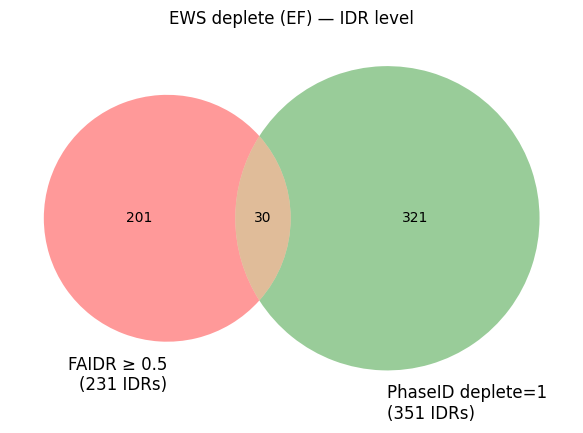

  Venn (IDR): intersection = 30, only FAIDR = 201, only PhaseID = 321
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_deplete_EF/venn_above_threshold_EWS_deplete.png

EWS_enrich_EF: 284 IDRs (score ≥ 0.5), 275 unique UniProt IDs
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_enrich_EF/above_threshold_EWS_enrich


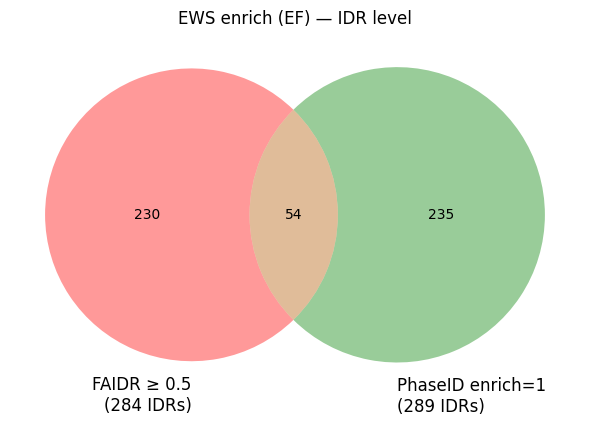

  Venn (IDR): intersection = 54, only FAIDR = 230, only PhaseID = 235
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_enrich_EF/venn_above_threshold_EWS_enrich.png

SP1_deplete_EF: 383 IDRs (score ≥ 0.5), 372 unique UniProt IDs
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/SP1_deplete_EF/above_threshold_SP1_deplete


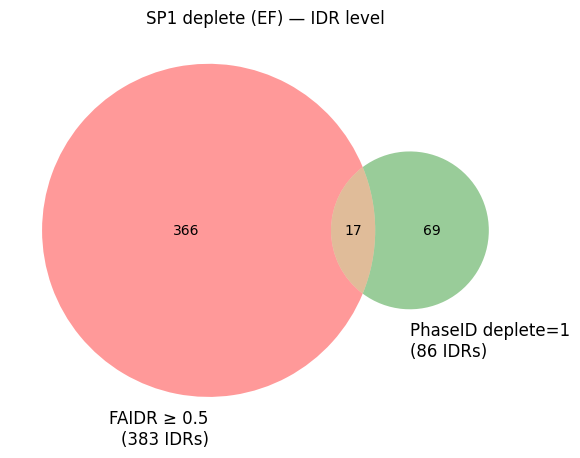

  Venn (IDR): intersection = 17, only FAIDR = 366, only PhaseID = 69
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/SP1_deplete_EF/venn_above_threshold_SP1_deplete.png

SP1_enrich_EF: 238 IDRs (score ≥ 0.5), 234 unique UniProt IDs
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/SP1_enrich_EF/above_threshold_SP1_enrich


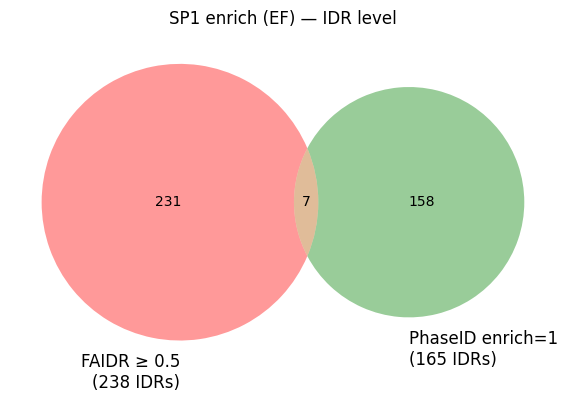

  Venn (IDR): intersection = 7, only FAIDR = 231, only PhaseID = 158
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/SP1_enrich_EF/venn_above_threshold_SP1_enrich.png

TAF_deplete_EF: 231 IDRs (score ≥ 0.5), 225 unique UniProt IDs
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/TAF_deplete_EF/above_threshold_TAF_deplete


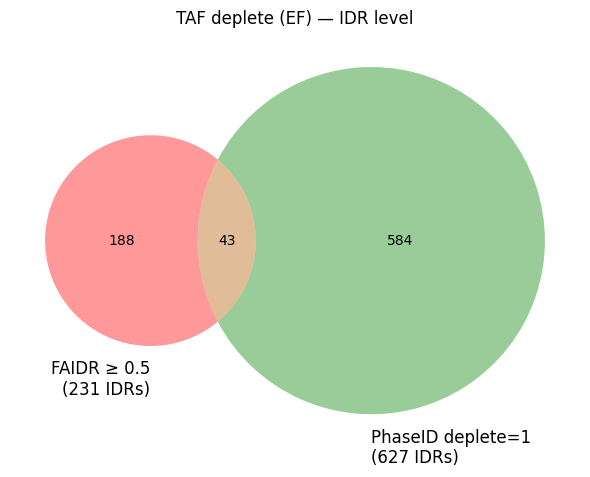

  Venn (IDR): intersection = 43, only FAIDR = 188, only PhaseID = 584
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/TAF_deplete_EF/venn_above_threshold_TAF_deplete.png

TAF_enrich_EF: 210 IDRs (score ≥ 0.5), 205 unique UniProt IDs
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/TAF_enrich_EF/above_threshold_TAF_enrich


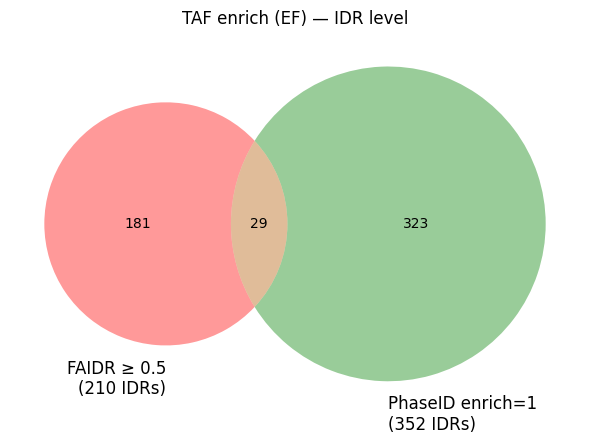

  Venn (IDR): intersection = 29, only FAIDR = 181, only PhaseID = 323
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/TAF_enrich_EF/venn_above_threshold_TAF_enrich.png

--- Summary ---


,run,IDRs_above_threshold,UniProt_above_threshold,PhaseID_positive_IDRs,intersection_IDRs,only_FAIDR_IDRs,only_PhaseID_IDRs
0,EWS_deplete_EF,231,223,351,30,201,321
1,EWS_enrich_EF,284,275,289,54,230,235
2,SP1_deplete_EF,383,372,86,17,366,69
3,SP1_enrich_EF,238,234,165,7,231,158
4,TAF_deplete_EF,231,225,627,43,188,584
5,TAF_enrich_EF,210,205,352,29,181,323


In [14]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

FAIDR_ROOT = PROJECT_ROOT / "FAIDR_output"
ABOVE_FILE = "IDR_above_cut_bal_control_no_cv.txt"
SCORE_THRESHOLD = 0.5

EF_THRESHOLD_RUNS = [
    "EWS_deplete_EF", "EWS_enrich_EF",
    "SP1_deplete_EF", "SP1_enrich_EF",
    "TAF_deplete_EF", "TAF_enrich_EF",
]


def uniprot_from_idr(idr_name: str) -> str:
    """UniProt accession = part of idr_name before the first '_'."""
    return str(idr_name).split("_", 1)[0]


def parse_ef_run(run_name: str) -> tuple[str, str]:
    """EWS_deplete_EF -> ('EWS', 'deplete')."""
    base = run_name.removesuffix("_EF")
    sample, condition = base.rsplit("_", 1)
    return sample, condition


def phaseid_positive_idrs(label_path: Path, condition: str) -> set[str]:
    labels = pd.read_csv(label_path, sep="\t")
    col = "deplete" if condition == "deplete" else "enrich"
    return set(labels.loc[labels[col] == 1, "idr_name"].astype(str))


threshold_summary = []

for run_name in EF_THRESHOLD_RUNS:
    run_dir = FAIDR_ROOT / run_name
    sample, condition = parse_ef_run(run_name)
    out_stem = f"above_threshold_{sample}_{condition}"

    scores = pd.read_csv(run_dir / ABOVE_FILE, sep="\t")
    score_col = [c for c in scores.columns if c != "idr_name"][0]
    above = scores.loc[scores[score_col] >= SCORE_THRESHOLD].copy()
    above["uniprot"] = above["idr_name"].map(uniprot_from_idr)

    n_idr = len(above)
    n_genes = above["uniprot"].nunique()
    print(f"\n{run_name}: {n_idr} IDRs (score ≥ {SCORE_THRESHOLD}), {n_genes} unique UniProt IDs")

    out_path = run_dir / out_stem
    above.to_csv(out_path, sep="\t", index=False)
    print(f"  saved → {out_path}")

    faidr_idrs = set(above["idr_name"].astype(str))
    phaseid_idrs = phaseid_positive_idrs(OUTPUT_DIR / f"{run_name}.txt", condition)

    only_faidr = faidr_idrs - phaseid_idrs
    only_phaseid = phaseid_idrs - faidr_idrs
    both = faidr_idrs & phaseid_idrs

    threshold_summary.append({
        "run": run_name,
        "IDRs_above_threshold": n_idr,
        "UniProt_above_threshold": n_genes,
        "PhaseID_positive_IDRs": len(phaseid_idrs),
        "intersection_IDRs": len(both),
        "only_FAIDR_IDRs": len(only_faidr),
        "only_PhaseID_IDRs": len(only_phaseid),
    })

    fig, ax = plt.subplots(figsize=(6, 5))
    venn2(
        [faidr_idrs, phaseid_idrs],
        set_labels=(
            f"FAIDR ≥ {SCORE_THRESHOLD}\n({len(faidr_idrs)} IDRs)",
            f"PhaseID {condition}=1\n({len(phaseid_idrs)} IDRs)",
        ),
        ax=ax,
    )
    ax.set_title(f"{sample} {condition} (EF) — IDR level")
    plt.tight_layout()
    venn_path = run_dir / f"venn_{out_stem}.png"
    fig.savefig(venn_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(
        f"  Venn (IDR): intersection = {len(both)}, "
        f"only FAIDR = {len(only_faidr)}, only PhaseID = {len(only_phaseid)}"
    )
    print(f"  saved → {venn_path}")

print("\n--- Summary ---")
display(pd.DataFrame(threshold_summary))

## Step 3 — Feature presence in `Tstats` (EF runs)

For each EF run, read all files in `Tstats/` (`Tstats_rep_001.txt` … `Tstats_rep_100.txt`).

For every **feature** (row in those files), count **how many reps** have a **non-NA** `t_stat` (feature was selected in glmnet that rep and got a t-statistic).

Results are saved per run as `Tstats/feature_non_NA_counts_<run>.txt`.

In [15]:
FAIDR_ROOT = PROJECT_ROOT / "FAIDR_output"
TSTATS_GLOB = "Tstats_rep_*.txt"

EF_TSTATS_RUNS = [
    "EWS_deplete_EF", "EWS_enrich_EF",
    "SP1_deplete_EF", "SP1_enrich_EF",
    "TAF_deplete_EF", "TAF_enrich_EF",
]


def count_non_na_tstats(run_dir: Path) -> pd.DataFrame:
    """Per feature: number of rep files where t_stat is not NA."""
    tstats_dir = run_dir / "Tstats"
    rep_files = sorted(tstats_dir.glob(TSTATS_GLOB))
    if not rep_files:
        raise FileNotFoundError(f"No Tstats files in {tstats_dir}")

    counts: dict[str, int] = {}
    n_reps = len(rep_files)

    for rep_path in rep_files:
        df = pd.read_csv(rep_path, sep="\t")
        present = df.loc[df["t_stat"].notna(), "feature"].astype(str)
        for feat in present:
            counts[feat] = counts.get(feat, 0) + 1

    out = pd.DataFrame({
        "feature": list(counts.keys()),
        "n_non_NA": list(counts.values()),
    })
    all_features = pd.read_csv(rep_files[0], sep="\t")["feature"].astype(str)
    out = all_features.to_frame(name="feature").merge(out, on="feature", how="left")
    out["n_non_NA"] = out["n_non_NA"].fillna(0).astype(int)
    out["frac_non_NA"] = out["n_non_NA"] / n_reps
    out = out.sort_values("n_non_NA", ascending=False).reset_index(drop=True)
    out.attrs["n_reps"] = n_reps
    return out


tstats_summary_rows = []

for run_name in EF_TSTATS_RUNS:
    run_dir = FAIDR_ROOT / run_name
    counts_df = count_non_na_tstats(run_dir)
    n_reps = counts_df.attrs["n_reps"]

    out_path = run_dir / "Tstats" / f"feature_non_NA_counts_{run_name}.txt"
    counts_df.to_csv(out_path, sep="\t", index=False)

    n_any = (counts_df["n_non_NA"] > 0).sum()
    print(f"\n{run_name}  ({n_reps} reps)")
    print(f"  features with ≥1 non-NA t_stat: {n_any} / {len(counts_df)}")
    print(f"  saved → {out_path}")
    display(counts_df.head(15))

    top = counts_df[counts_df["n_non_NA"] > 0].head(5)
    for _, row in top.iterrows():
        tstats_summary_rows.append({
            "run": run_name,
            "feature": row["feature"],
            "n_non_NA": row["n_non_NA"],
            "frac_non_NA": row["frac_non_NA"],
        })

print("\n--- Top features per run (up to 5 with any non-NA) ---")
display(pd.DataFrame(tstats_summary_rows))


EWS_deplete_EF  (100 reps)
  features with ≥1 non-NA t_stat: 54 / 145
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_deplete_EF/Tstats/feature_non_NA_counts_EWS_deplete_EF.txt


,feature,n_non_NA,frac_non_NA
0,(Intercept),100,1.00
1,Q_homorep,100,1.00
2,TRG_NLS_MonoExtN_4,100,1.00
3,MOD_SUMO_for_1,100,1.00
4,RK_ratio,97,0.97
5,AA_W,94,0.94
6,D_homorep,94,0.94
7,AA_V,81,0.81
8,id.REP_PR..PR..2..,80,0.80
9,id.REP_S2.S.2.2.,78,0.78



EWS_enrich_EF  (100 reps)
  features with ≥1 non-NA t_stat: 66 / 145
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_enrich_EF/Tstats/feature_non_NA_counts_EWS_enrich_EF.txt


,feature,n_non_NA,frac_non_NA
0,(Intercept),100,1.00
1,DOC_MAPK_gen_1,100,1.00
2,ED_ratio,100,1.00
3,id.REP_QN2..QN..2..,96,0.96
4,MOD_CK2_1,91,0.91
5,AA_L,90,0.90
6,AA_C,82,0.82
7,PG_rich,78,0.78
8,MOD_PKA_2,77,0.77
9,AA_Q,76,0.76



SP1_deplete_EF  (100 reps)
  features with ≥1 non-NA t_stat: 117 / 145
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/SP1_deplete_EF/Tstats/feature_non_NA_counts_SP1_deplete_EF.txt


...

,feature,n_non_NA,frac_non_NA
0,(Intercept),100,1.00
1,RK_ratio,100,1.00
2,TRG_NLS_MonoExtN_4,100,1.00
3,LIG_14.3.3_CanoR_1,100,1.00
4,AA_W,100,1.00
5,A_homorep,98,0.98
6,MOD_SUMO_for_1,75,0.75
7,S_homorep,73,0.73
8,id.REP_E2.E.2.2.,60,0.60
9,G_homorep,47,0.47



TAF_enrich_EF  (100 reps)
  features with ≥1 non-NA t_stat: 35 / 145
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/TAF_enrich_EF/Tstats/feature_non_NA_counts_TAF_enrich_EF.txt


,feature,n_non_NA,frac_non_NA
0,(Intercept),100,1.00
1,ED_ratio,100,1.00
2,AA_L,99,0.99
3,MOD_PKA_2,97,0.97
4,id.REP_Q2.Q.2.2.,92,0.92
5,SGFYSG,89,0.89
6,RK_ratio,81,0.81
7,AA_N,80,0.80
8,net_charge,75,0.75
9,id.REP_QN2..QN..2..,71,0.71



--- Top features per run (up to 5 with any non-NA) ---


,run,feature,n_non_NA,frac_non_NA
0,EWS_deplete_EF,(Intercept),100,1.00
1,EWS_deplete_EF,Q_homorep,100,1.00
2,EWS_deplete_EF,TRG_NLS_MonoExtN_4,100,1.00
3,EWS_deplete_EF,MOD_SUMO_for_1,100,1.00
4,EWS_deplete_EF,RK_ratio,97,0.97
5,EWS_enrich_EF,(Intercept),100,1.00
6,EWS_enrich_EF,DOC_MAPK_gen_1,100,1.00
7,EWS_enrich_EF,ED_ratio,100,1.00
8,EWS_enrich_EF,id.REP_QN2..QN..2..,96,0.96
9,EWS_enrich_EF,MOD_CK2_1,91,0.91


## Step 4 — T-stat heatmap (features with non-NA in ≥ 10% of reps)

Using the same 6 **EF** runs and their `Tstats/` files:

1. Keep features with **non-NA `t_stat` in ≥ 10%** of reps (≥ 10 / 100) **and** `same_sign_frac ≥ 70%`.
2. For each kept feature, compute:
   - **mean** t-stat (over non-NA reps)
   - **std** t-stat (over non-NA reps)
   - **n_non_NA** — in how many reps the feature had a non-NA t-stat (out of 100)
   - **same_sign_frac** — used for filtering only (saved in the table, not shown on the heatmap)
3. For each kept feature, also compute **mean EF score among positive IDRs** (mean over IDRs in `above_threshold_<sample>_<condition>`, FAIDR ≥ 0.5; Step 2).
4. Plot a **4-column heatmap** (mean t-stat, std, n_non_NA, mean EF score among positive IDRs), each with its **own color scale / legend**. Mean t-stat and mean EF score use **RdBu_r** (diverging, centered at 0).

`(Intercept)` is excluded from the heatmap (very different scale); it remains in the saved table.


EWS_deplete_EF: 32 features (non-NA ≥ 10%, same_sign ≥ 70%; Intercept excluded)


,feature,n_non_NA,frac_non_NA,mean_t_stat,std_t_stat,same_sign_frac,mean_ef_score_positive_idrs,n_idr_above_threshold
0,TRG_NLS_MonoExtN_4,100,1.00,31.802253,5.997136,1.0000,11.994649,231
1,Q_homorep,100,1.00,24.401993,6.251838,1.0000,6.827811,231
2,RK_ratio,97,0.97,-16.073984,7.441671,1.0000,-10.853661,231
3,MOD_SUMO_for_1,100,1.00,14.770383,3.858472,1.0000,5.372951,231
4,AA_V,81,0.81,11.734389,5.081927,1.0000,3.467529,231
5,D_homorep,94,0.94,10.141449,4.834173,1.0000,6.762424,231
6,AA_W,94,0.94,-9.680265,5.249174,1.0000,-4.338824,231
7,AA_K,68,0.68,8.242127,5.993587,1.0000,9.951027,231
8,id.REP_S2.S.2.2.,78,0.78,7.000814,4.887463,1.0000,1.104828,231
9,id.REP_PR..PR..2..,80,0.80,-6.794725,4.594193,0.9625,-4.221910,231


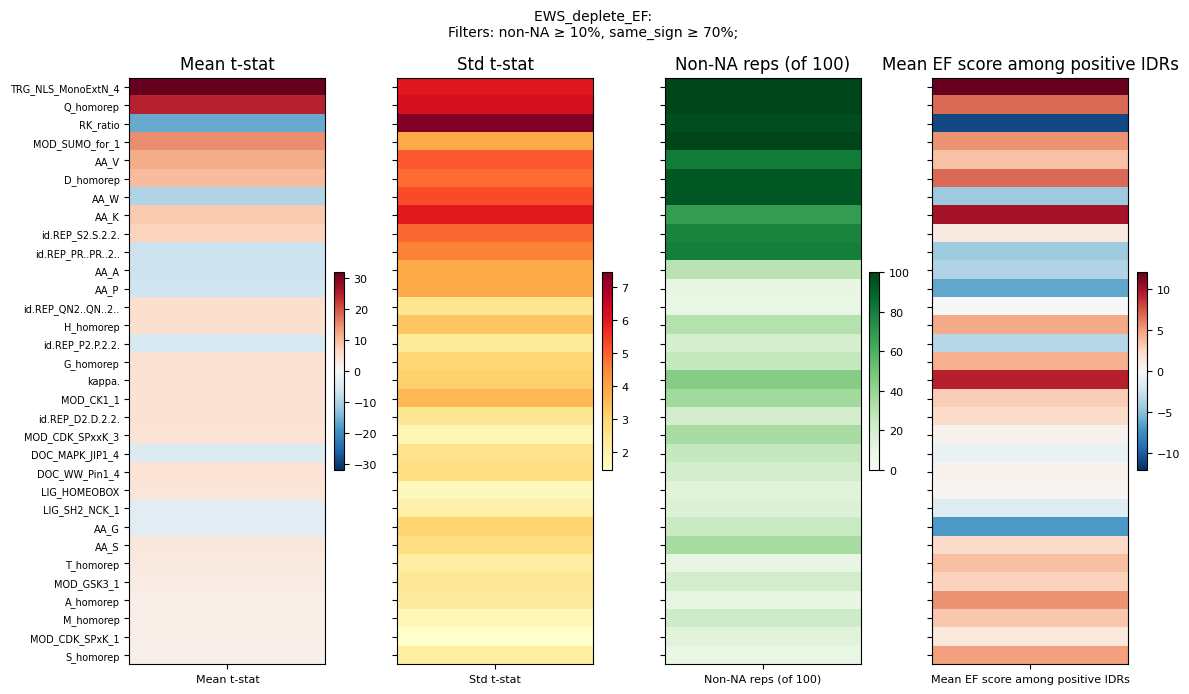

  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_deplete_EF/Tstats/heatmap_tstat_summary_EWS_deplete_EF.png

EWS_enrich_EF: 28 features (non-NA ≥ 10%, same_sign ≥ 70%; Intercept excluded)


,feature,n_non_NA,frac_non_NA,mean_t_stat,std_t_stat,same_sign_frac,mean_ef_score_positive_idrs,n_idr_above_threshold
0,ED_ratio,100,1.00,-33.851989,5.950237,1.000000,-10.327769,284
1,DOC_MAPK_gen_1,100,1.00,-22.089701,5.303119,1.000000,-3.582348,284
2,AA_L,90,0.90,-10.895242,5.890110,1.000000,-4.299774,284
3,MOD_GSK3_1,39,0.39,-7.848821,2.789979,1.000000,0.690367,284
4,id.REP_QN2..QN..2..,96,0.96,7.747179,5.708686,0.947917,6.971254,284
5,AA_Q,76,0.76,7.648881,4.449507,1.000000,7.046185,284
6,MOD_CK2_1,91,0.91,-7.374271,5.626300,0.923077,-8.640691,284
7,AA_H,29,0.29,6.293178,4.099298,1.000000,2.645391,284
8,A_homorep,20,0.20,6.024341,4.133237,1.000000,5.379790,284
9,MOD_PKA_2,77,0.77,-5.930657,5.488128,0.935065,-5.665969,284


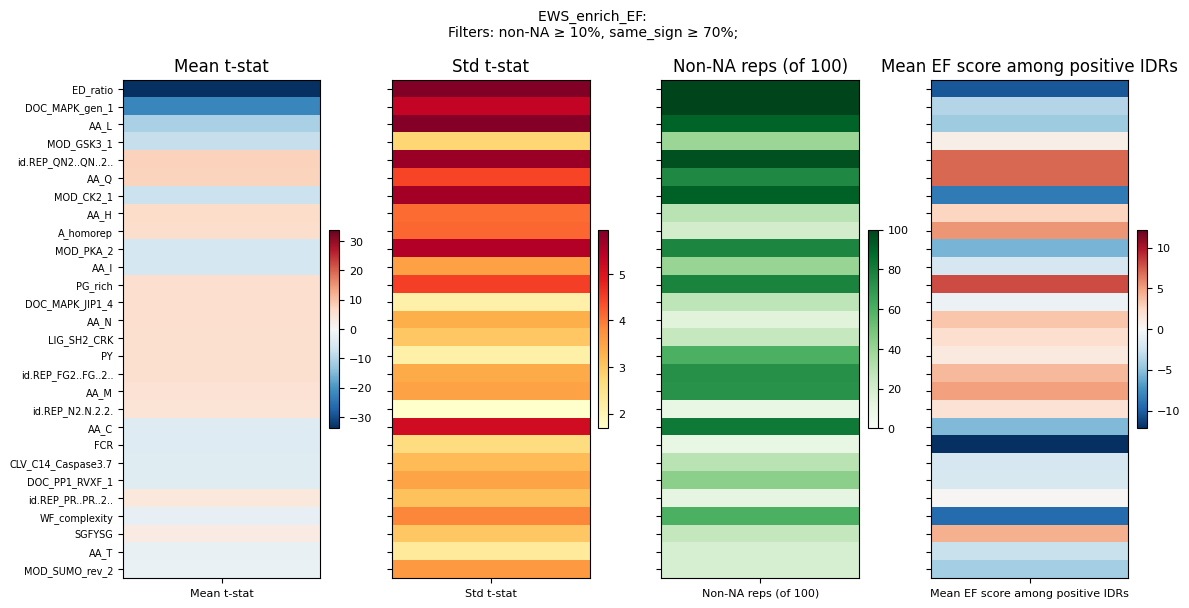

  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_enrich_EF/Tstats/heatmap_tstat_summary_EWS_enrich_EF.png

SP1_deplete_EF: 44 features (non-NA ≥ 10%, same_sign ≥ 70%; Intercept excluded)


,feature,n_non_NA,frac_non_NA,mean_t_stat,std_t_stat,same_sign_frac,mean_ef_score_positive_idrs,n_idr_above_threshold
0,AA_L,97,0.97,-11.094325,11.940680,0.958763,-4.872327,383
1,AA_I,17,0.17,10.427364,5.749271,1.000000,-0.757871,383
2,DOC_MAPK_JIP1_4,94,0.94,-10.089967,10.326455,0.978723,-1.349641,383
3,TRG_NLS_MonoExtN_4,54,0.54,7.793152,6.876040,0.981481,3.218312,383
4,LIG_KLC1_WD_1,57,0.57,-7.497009,7.611447,1.000000,-1.007148,383
5,TRG_LysEnd_APsAcLL_1,35,0.35,6.892434,6.731915,1.000000,-1.599680,383
6,MOD_N.GLC_1,34,0.34,6.627378,6.658360,1.000000,1.403159,383
7,id.REP_SG2..SG..2..,30,0.30,-6.084959,3.066075,1.000000,-0.039977,383
8,LIG_EH_1,77,0.77,-6.060433,6.564987,0.961039,-0.100765,383
9,id.REP_G2.G.2.2.,11,0.11,-6.054364,5.262230,0.909091,1.817611,383


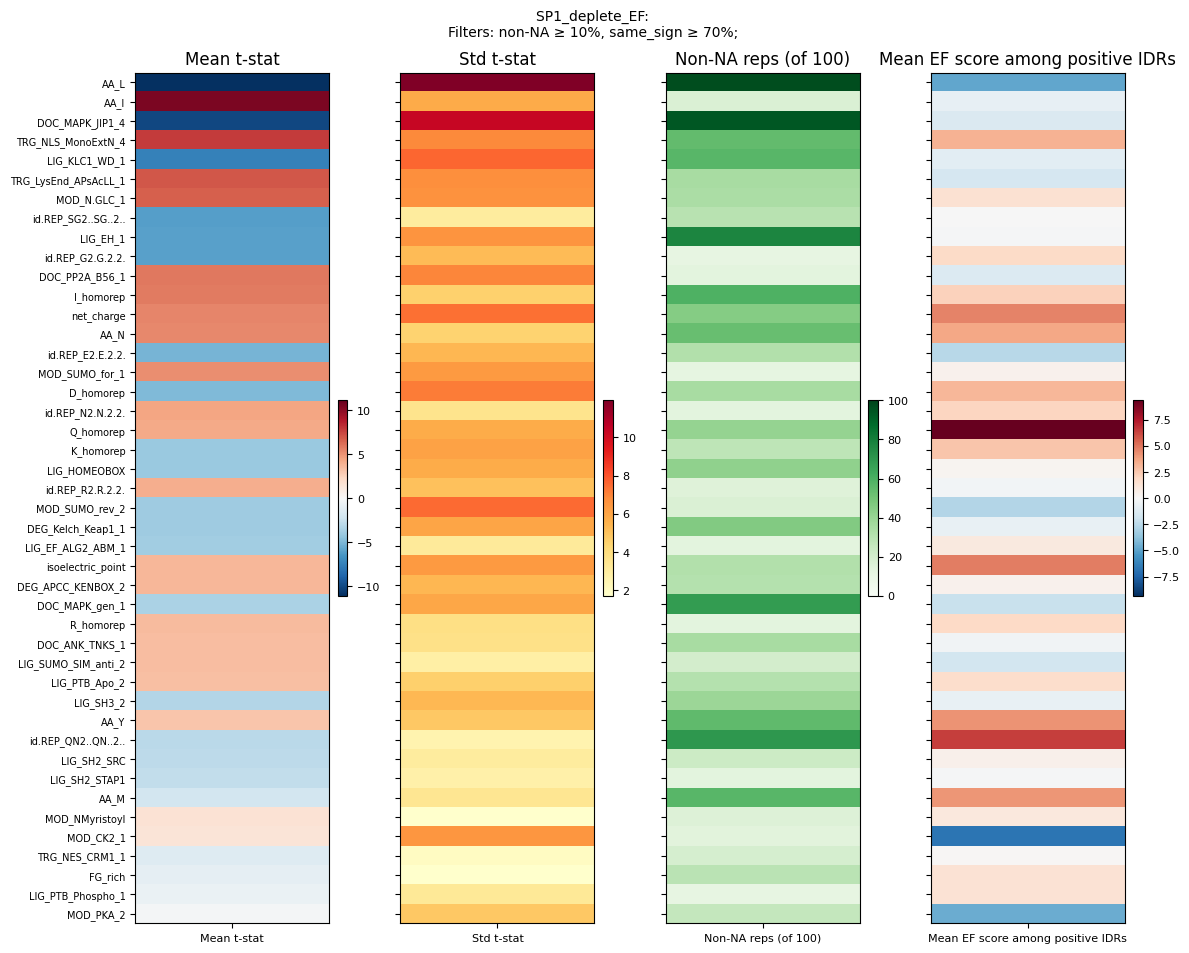

  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/SP1_deplete_EF/Tstats/heatmap_tstat_summary_SP1_deplete_EF.png

SP1_enrich_EF: 30 features (non-NA ≥ 10%, same_sign ≥ 70%; Intercept excluded)


,feature,n_non_NA,frac_non_NA,mean_t_stat,std_t_stat,same_sign_frac,mean_ef_score_positive_idrs,n_idr_above_threshold
0,AA_D,99,0.99,25.334979,10.432819,1.0,12.691773,238
1,AA_L,94,0.94,-24.011833,10.745110,1.0,-7.679420,238
2,id.REP_E2.E.2.2.,100,1.00,20.197955,9.438868,1.0,11.959721,238
3,DOC_MAPK_MEF2A_6,39,0.39,-11.565275,8.374770,1.0,-2.226186,238
4,id.REP_S2.S.2.2.,65,0.65,11.125982,6.768356,1.0,-0.704531,238
5,AA_W,23,0.23,-10.025222,5.443075,1.0,-2.102978,238
6,G_homorep,41,0.41,9.022623,6.733451,1.0,3.807484,238
7,FRG,36,0.36,-8.632956,5.445634,1.0,-1.234234,238
8,AA_K,25,0.25,8.424974,5.818315,1.0,4.734315,238
9,LIG_PAM2_1,10,0.10,8.412062,5.273619,0.9,-0.096171,238


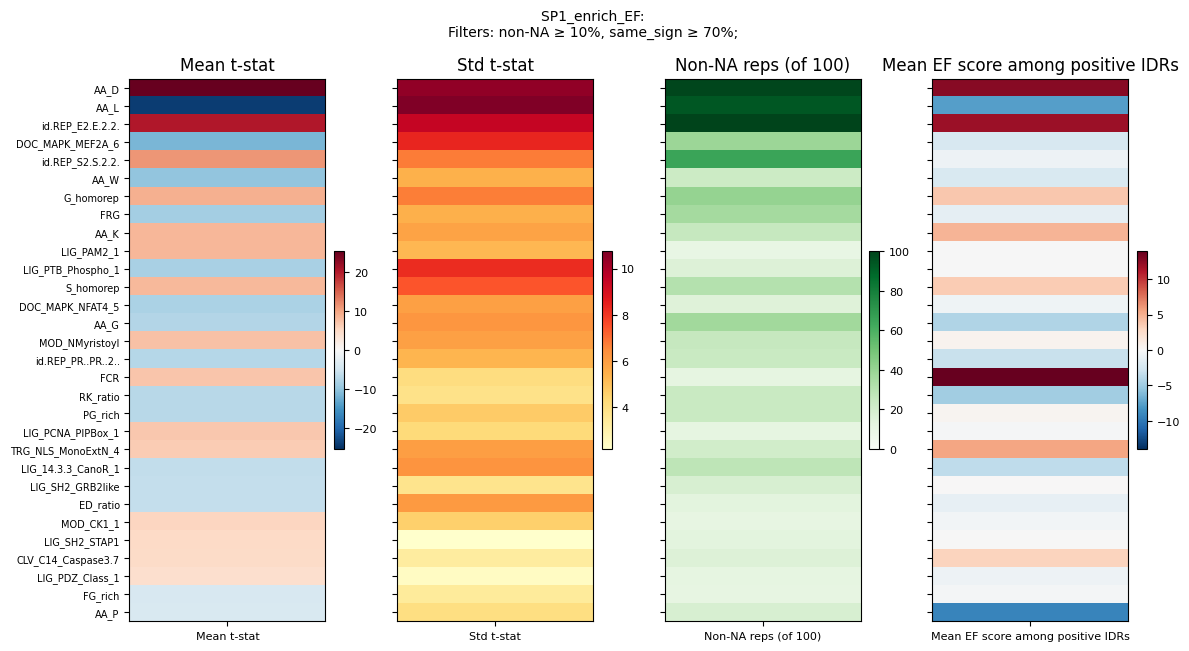

  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/SP1_enrich_EF/Tstats/heatmap_tstat_summary_SP1_enrich_EF.png

TAF_deplete_EF: 23 features (non-NA ≥ 10%, same_sign ≥ 70%; Intercept excluded)


,feature,n_non_NA,frac_non_NA,mean_t_stat,std_t_stat,same_sign_frac,mean_ef_score_positive_idrs,n_idr_above_threshold
0,TRG_NLS_MonoExtN_4,100,1.00,29.950569,3.990719,1.0,12.790249,231
1,RK_ratio,100,1.00,-16.555305,4.552170,1.0,-11.383944,231
2,AA_W,100,1.00,-16.427052,3.681204,1.0,-4.463188,231
3,LIG_14.3.3_CanoR_1,100,1.00,-13.897136,3.416696,1.0,-4.701917,231
4,A_homorep,98,0.98,9.959052,3.587266,1.0,6.060720,231
5,MOD_SUMO_for_1,75,0.75,6.764455,2.508637,1.0,4.203443,231
6,S_homorep,73,0.73,6.333740,2.978683,1.0,4.680478,231
7,id.REP_D2.D.2.2.,44,0.44,5.222046,2.134617,1.0,3.024374,231
8,AA_D,17,0.17,5.137399,2.010276,1.0,4.034853,231
9,MOD_CDK_SPxK_1,21,0.21,5.098093,1.578384,1.0,1.025953,231


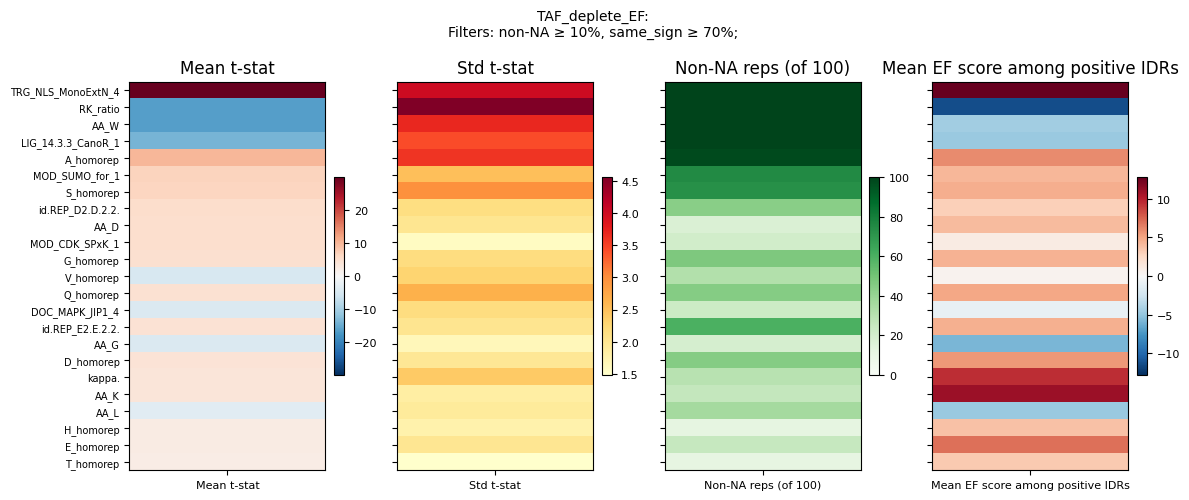

  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/TAF_deplete_EF/Tstats/heatmap_tstat_summary_TAF_deplete_EF.png

TAF_enrich_EF: 15 features (non-NA ≥ 10%, same_sign ≥ 70%; Intercept excluded)


,feature,n_non_NA,frac_non_NA,mean_t_stat,std_t_stat,same_sign_frac,mean_ef_score_positive_idrs,n_idr_above_threshold
0,AA_L,99,0.99,-16.738457,4.159997,1.0,-5.220011,210
1,ED_ratio,100,1.00,-15.829052,3.907733,1.0,-9.198806,210
2,MOD_PKA_2,97,0.97,-11.453406,3.670748,1.0,-6.623717,210
3,SGFYSG,89,0.89,9.009557,3.033231,1.0,5.041801,210
4,id.REP_Q2.Q.2.2.,92,0.92,8.854450,4.709060,1.0,10.224706,210
5,RK_ratio,81,0.81,-7.961618,3.379301,1.0,-0.129499,210
6,net_charge,75,0.75,7.254597,3.044642,1.0,3.363565,210
7,AA_N,80,0.80,7.247446,2.954264,1.0,5.448901,210
8,MOD_SUMO_rev_2,24,0.24,5.403547,1.216946,1.0,-3.142465,210
9,Q_homorep,71,0.71,5.125748,2.828937,1.0,11.074250,210


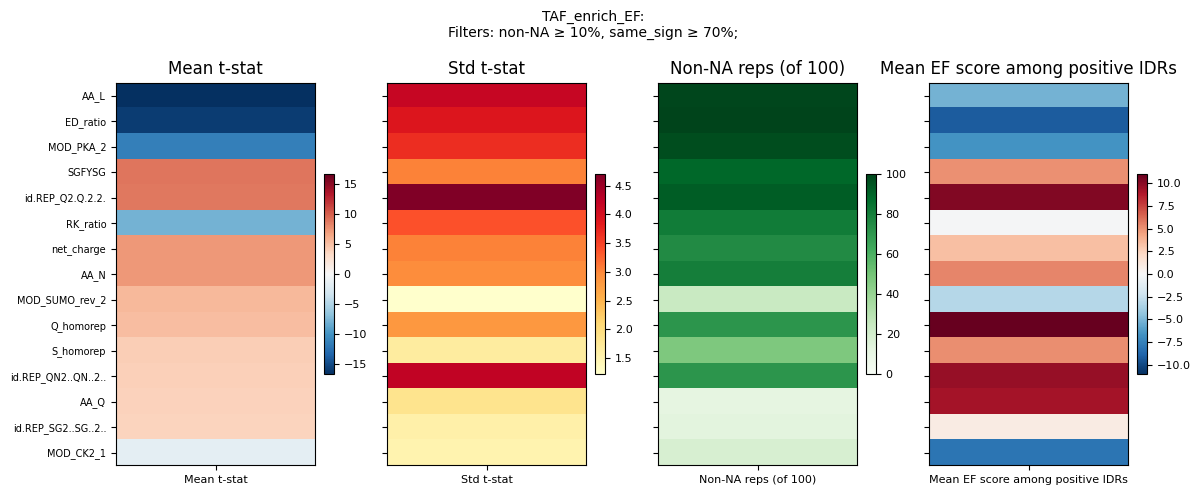

  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/TAF_enrich_EF/Tstats/heatmap_tstat_summary_TAF_enrich_EF.png

--- Heatmap outputs ---


,run,n_reps,n_features_ge10pct,summary_table,heatmap_png
0,EWS_deplete_EF,100,32,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...
1,EWS_enrich_EF,100,28,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...
2,SP1_deplete_EF,100,44,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...
3,SP1_enrich_EF,100,30,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...
4,TAF_deplete_EF,100,23,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...
5,TAF_enrich_EF,100,15,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

MIN_FRAC_NON_NA = 0.10  # keep features with non-NA in >= 10% of reps
MIN_SAME_SIGN_FRAC = 0.70  # keep features with same-sign fraction >= 70% (of non-NA reps)

MEAN_EF_POS_COL = "mean_ef_score_positive_idrs"
MEAN_EF_POS_LABEL = "Mean EF score among positive IDRs"


def load_tstats_matrix(tstats_dir: Path) -> tuple[pd.DataFrame, int]:
    rep_files = sorted(tstats_dir.glob(TSTATS_GLOB))
    if not rep_files:
        raise FileNotFoundError(f"No Tstats files in {tstats_dir}")
    features = pd.read_csv(rep_files[0], sep="\t")["feature"].astype(str)
    mat = pd.DataFrame(index=features, columns=range(len(rep_files)), dtype=float)
    for i, rep_path in enumerate(rep_files):
        df = pd.read_csv(rep_path, sep="\t")
        s = df.set_index(df["feature"].astype(str))["t_stat"]
        mat.loc[s.index, i] = s.values
    return mat, len(rep_files)


def same_sign_frac(row: pd.Series) -> float:
    """Fraction of non-NA reps where t_stat has the majority sign."""
    vals = row.dropna()
    if len(vals) == 0:
        return 0.0
    n_pos = (vals > 0).sum()
    n_neg = (vals < 0).sum()
    return float(max(n_pos, n_neg) / len(vals))


_step4_human_es_cache: pd.DataFrame | None = None
_step4_tstat_to_es_cache: dict[str, dict[str, str]] = {}


def _load_human_es_for_step4() -> pd.DataFrame:
    global _step4_human_es_cache
    if _step4_human_es_cache is None:
        df = pd.read_csv(EF_PATH, sep="\t")
        df = df[df["idr_name"].notna() & df["idr_name"].astype(str).str.len().gt(0)]
        feature_cols = [c for c in df.columns if c not in ("idr_name", "NAME")]
        df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
        _step4_human_es_cache = df
    return _step4_human_es_cache


def _build_tstat_to_es_map_step4(tstats_dir: Path) -> dict[str, str]:
    key = str(tstats_dir.resolve())
    if key not in _step4_tstat_to_es_cache:
        rep_path = sorted(tstats_dir.glob(TSTATS_GLOB))[0]
        tstats_feats = pd.read_csv(rep_path, sep="\t")["feature"].astype(str).tolist()
        es_cols = [c for c in _load_human_es_for_step4().columns if c not in ("idr_name", "NAME")]
        tstats_feats = [f for f in tstats_feats if f != "(Intercept)"]
        _step4_tstat_to_es_cache[key] = dict(zip(tstats_feats, es_cols))
    return _step4_tstat_to_es_cache[key]


def _parse_ef_run_step4(run_name: str) -> tuple[str, str]:
    base = run_name.removesuffix("_EF")
    return base.rsplit("_", 1)


def _above_threshold_path_step4(run_name: str) -> Path:
    sample, condition = _parse_ef_run_step4(run_name)
    return FAIDR_ROOT / run_name / f"above_threshold_{sample}_{condition}"


def add_mean_es_above_threshold(
    summary: pd.DataFrame, run_name: str, tstats_dir: Path
) -> pd.DataFrame:
    """Append mean HUMAN_ES per feature over IDRs in above_threshold_* file."""
    at_path = _above_threshold_path_step4(run_name)
    if not at_path.exists():
        raise FileNotFoundError(f"Missing {at_path} — run Step 2 (above_threshold) first.")
    idr_set = set(pd.read_csv(at_path, sep="\t")["idr_name"].astype(str))
    human_es = _load_human_es_for_step4()
    sub = human_es[human_es["idr_name"].astype(str).isin(idr_set)]
    tstat_to_es = _build_tstat_to_es_map_step4(tstats_dir)

    mean_es = []
    for feat in summary["feature"].astype(str):
        es_col = tstat_to_es.get(feat)
        if es_col is None or es_col not in human_es.columns or sub.empty:
            mean_es.append(np.nan)
        else:
            mean_es.append(float(sub[es_col].mean()))
    out = summary.copy()
    out[MEAN_EF_POS_COL] = mean_es
    out["n_idr_above_threshold"] = len(idr_set)
    return out


def summarize_filtered_tstats(mat: pd.DataFrame, n_reps: int) -> pd.DataFrame:
    n_non_na = mat.notna().sum(axis=1)
    keep = n_non_na >= MIN_FRAC_NON_NA * n_reps
    sub = mat.loc[keep].copy()
    if "(Intercept)" in sub.index:
        sub = sub.drop(index="(Intercept)")

    summary = pd.DataFrame({
        "feature": sub.index,
        "n_non_NA": n_non_na.loc[sub.index].astype(int).values,
        "frac_non_NA": (n_non_na.loc[sub.index] / n_reps).values,
        "mean_t_stat": sub.mean(axis=1, skipna=True).values,
        "std_t_stat": sub.std(axis=1, skipna=True).values,
        "same_sign_frac": sub.apply(same_sign_frac, axis=1).values,
    })
    summary = summary[summary["same_sign_frac"] >= MIN_SAME_SIGN_FRAC]
    summary = summary.sort_values("mean_t_stat", key=np.abs, ascending=False).reset_index(drop=True)
    return summary


def plot_tstat_summary_heatmap(summary: pd.DataFrame, run_name: str, n_reps: int, save_path: Path):
    if summary.empty:
        print(
            f"{run_name}: no features pass filters "
            f"(≥{MIN_FRAC_NON_NA:.0%} non-NA, same_sign ≥{MIN_SAME_SIGN_FRAC:.0%}; Intercept excluded)"
        )
        return

    features = summary["feature"].tolist()
    n_idr_at = int(summary["n_idr_above_threshold"].iloc[0]) if "n_idr_above_threshold" in summary.columns else 0
    cols = [
        ("mean_t_stat", "Mean t-stat", "RdBu_r", "diverging"),
        ("std_t_stat", "Std t-stat", "YlOrRd", "sequential"),
        ("n_non_NA", f"Non-NA reps (of {n_reps})", "Greens", "count"),
        (MEAN_EF_POS_COL, MEAN_EF_POS_LABEL, "RdBu_r", "diverging"),
    ]

    n_rows = len(features)
    fig_h = max(5, 0.22 * n_rows)
    fig, axes = plt.subplots(1, 4, figsize=(12, fig_h), gridspec_kw={"width_ratios": [1, 1, 1, 1]})

    ylabels = [f if len(f) <= 28 else f[:25] + "..." for f in features]

    for ax, (col, title, cmap, kind) in zip(axes, cols):
        values = summary[col].to_numpy(dtype=float).reshape(-1, 1)
        if kind == "diverging":
            vmax = float(np.nanmax(np.abs(values))) if values.size else 1.0
            norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax) if vmax > 0 else None
            im = ax.imshow(values, aspect="auto", cmap=cmap, norm=norm)
        elif kind == "count" and col == "n_non_NA":
            im = ax.imshow(values, aspect="auto", cmap=cmap, vmin=0, vmax=n_reps)
        else:
            im = ax.imshow(values, aspect="auto", cmap=cmap)
        ax.set_title(title)
        ax.set_xticks([0])
        ax.set_xticklabels([title.replace("\n", " ")], rotation=0, fontsize=8)
        ax.set_yticks(range(n_rows))
        ax.set_yticklabels(ylabels if ax is axes[0] else [], fontsize=7)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

    fig.suptitle(
        f"{run_name}: \n"
        f"Filters: non-NA ≥ {MIN_FRAC_NON_NA:.0%}, same_sign ≥ {MIN_SAME_SIGN_FRAC:.0%}; ",
        fontsize=10,
    )
    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  saved → {save_path}")


heatmap_summary_rows = []

for run_name in EF_TSTATS_RUNS:
    run_dir = FAIDR_ROOT / run_name
    mat, n_reps = load_tstats_matrix(run_dir / "Tstats")
    summary = summarize_filtered_tstats(mat, n_reps)
    summary = add_mean_es_above_threshold(summary, run_name, run_dir / "Tstats")

    table_path = run_dir / "Tstats" / f"tstat_summary_ge10pct_{run_name}.txt"
    summary.to_csv(table_path, sep="\t", index=False)

    n_pass = len(summary)
    print(
        f"\n{run_name}: {n_pass} features "
        f"(non-NA ≥ {MIN_FRAC_NON_NA:.0%}, same_sign ≥ {MIN_SAME_SIGN_FRAC:.0%}; Intercept excluded)"
    )
    display(summary.head(10))

    png_path = run_dir / "Tstats" / f"heatmap_tstat_summary_{run_name}.png"
    plot_tstat_summary_heatmap(summary, run_name, n_reps, png_path)

    heatmap_summary_rows.append({
        "run": run_name,
        "n_reps": n_reps,
        "n_features_ge10pct": n_pass,
        "summary_table": str(table_path),
        "heatmap_png": str(png_path),
    })

print("\n--- Heatmap outputs ---")
display(pd.DataFrame(heatmap_summary_rows))

## Step 4b — Paired heatmaps per bait (deplete vs enrich)

For each bait protein (**EWS**, **SP1**, **TAF**), place **deplete** and **enrich** side by side (same 3 columns as Step 4: mean, std, n_non_NA).

- **Shared feature rows** = union of features that passed Step 4 filters in **either** run.
- If a feature is missing in one run (filtered out or no data), that run’s cells are drawn **white**; the other run still shows its values.
- Color scales for mean / std / n_non_NA are shared within each metric across deplete and enrich for easier comparison.

/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(base_cmap).copy()
/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(base_cmap).copy()
/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap 

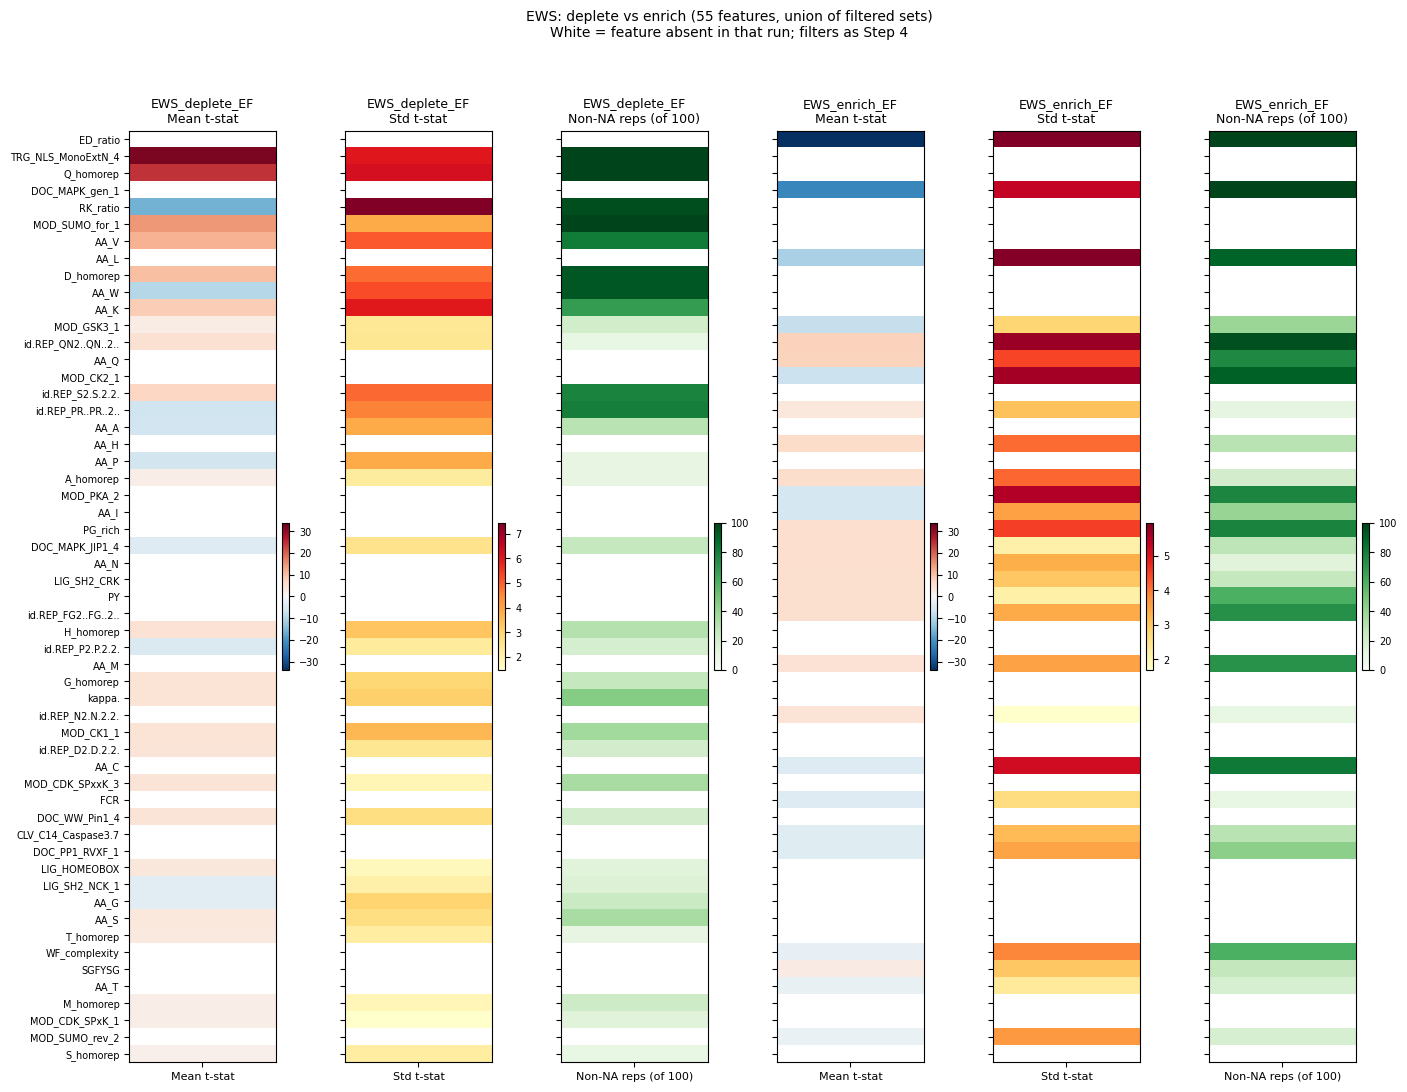

  EWS: 32 deplete + 28 enrich → 55 rows (union)
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_paired_EF/Tstats/heatmap_tstat_paired_EWS_deplete_vs_enrich.png


/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(base_cmap).copy()
/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(base_cmap).copy()
/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap 

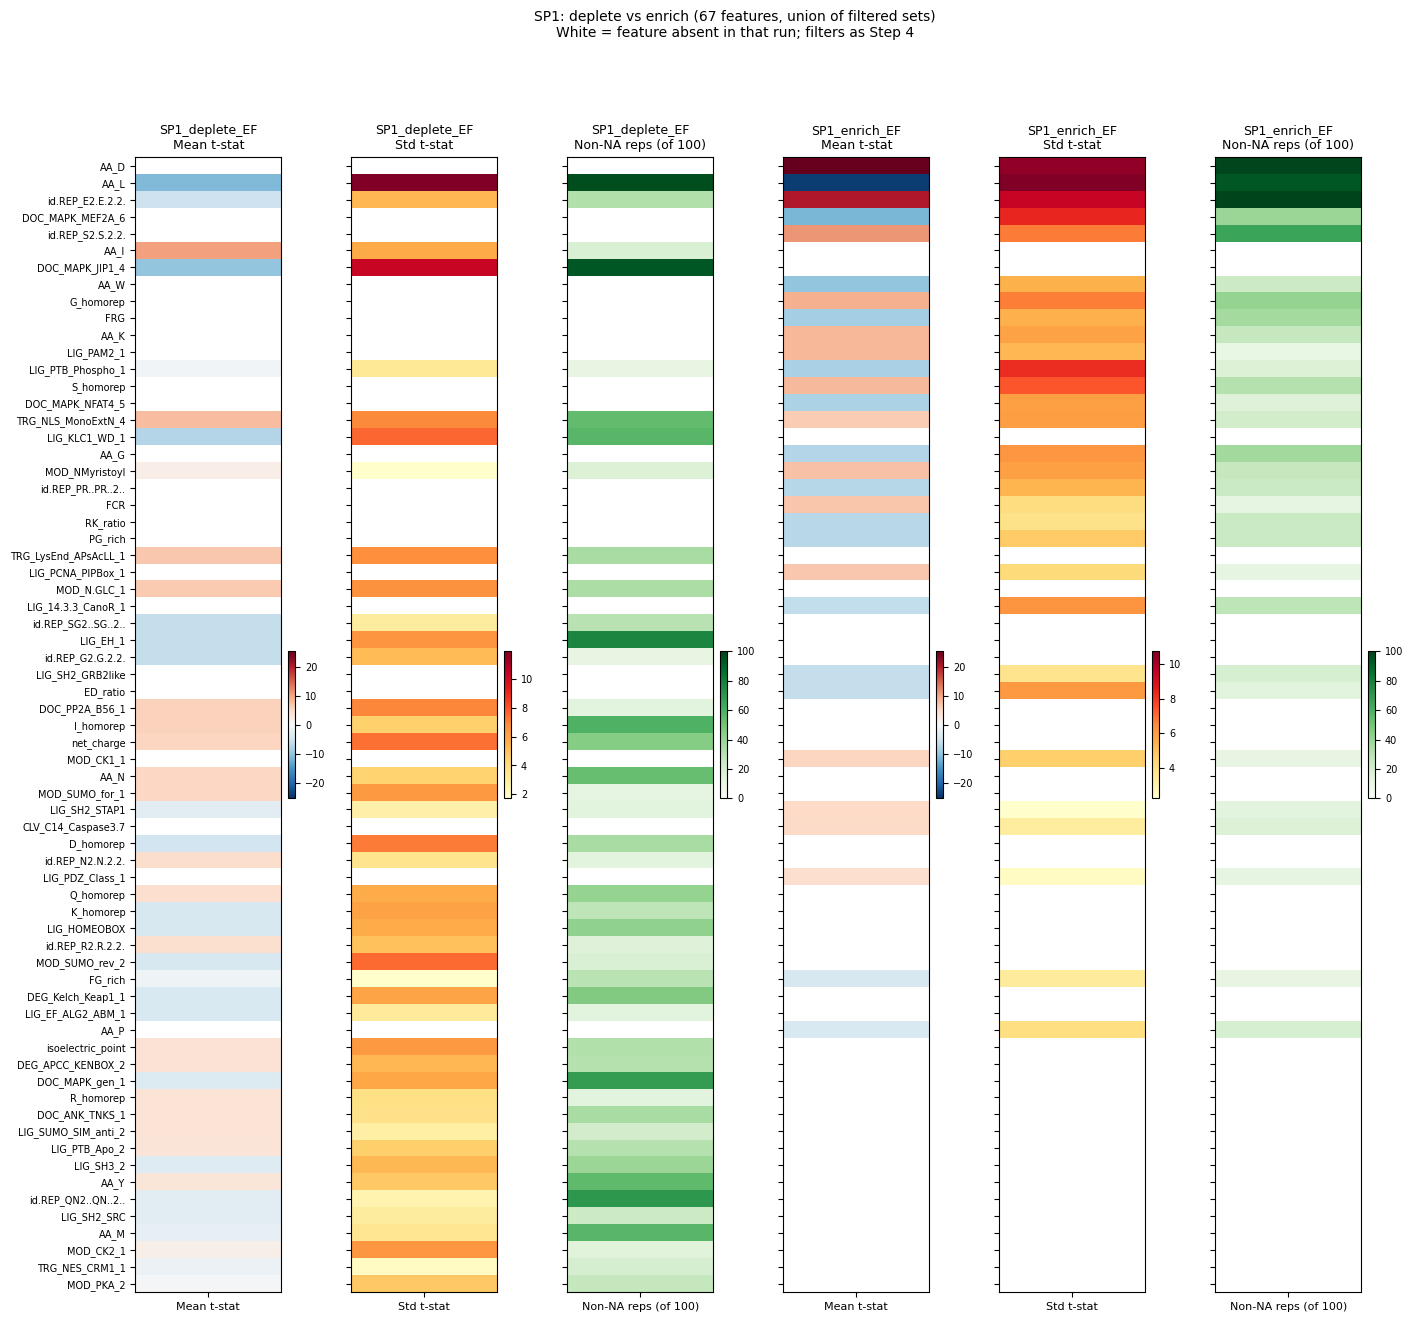

  SP1: 44 deplete + 30 enrich → 67 rows (union)
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/SP1_paired_EF/Tstats/heatmap_tstat_paired_SP1_deplete_vs_enrich.png


/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(base_cmap).copy()
/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(base_cmap).copy()
/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap 

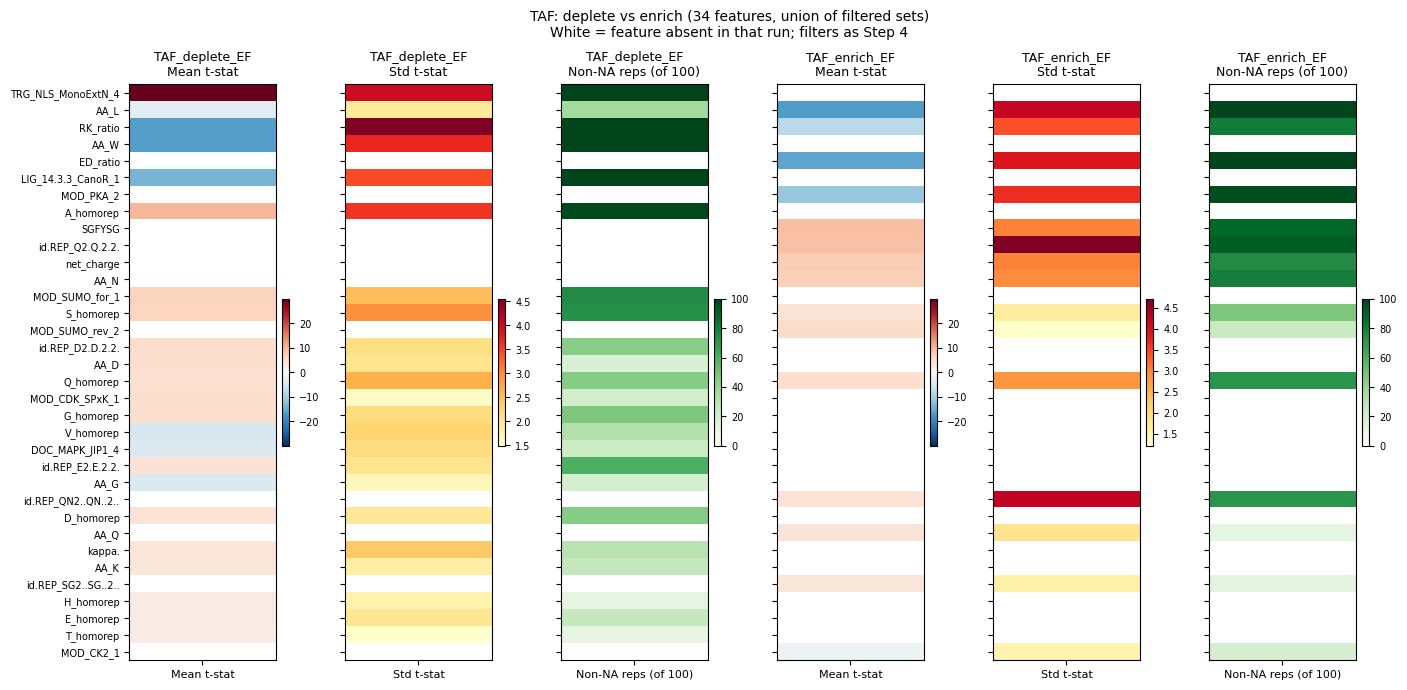

  TAF: 23 deplete + 15 enrich → 34 rows (union)
  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/TAF_paired_EF/Tstats/heatmap_tstat_paired_TAF_deplete_vs_enrich.png

--- Paired heatmap outputs ---


,bait,deplete_run,enrich_run,n_features_deplete,n_features_enrich,n_features_union,aligned_table,heatmap_png
0,EWS,EWS_deplete_EF,EWS_enrich_EF,32,28,55,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...
1,SP1,SP1_deplete_EF,SP1_enrich_EF,44,30,67,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...
2,TAF,TAF_deplete_EF,TAF_enrich_EF,23,15,34,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...


In [17]:
from matplotlib import cm

BAIT_PAIRS = [
    ("EWS", "EWS_deplete_EF", "EWS_enrich_EF"),
    ("SP1", "SP1_deplete_EF", "SP1_enrich_EF"),
    ("TAF", "TAF_deplete_EF", "TAF_enrich_EF"),
]

METRIC_COLS = [
    ("mean_t_stat", "Mean t-stat", "RdBu_r", "mean"),
    ("std_t_stat", "Std t-stat", "YlOrRd", "std"),
    ("n_non_NA", "Non-NA reps", "Greens", "count"),
]


def _masked_cmap(base_cmap: str):
    cmap = cm.get_cmap(base_cmap).copy()
    cmap.set_bad(color="white")
    return cmap


def align_summaries_for_pair(left: pd.DataFrame, right: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """Union of filtered features; missing rows filled with NaN (white on plot)."""
    left_set = set(left["feature"].astype(str))
    right_set = set(right["feature"].astype(str))

    def abs_mean(f: str, summary: pd.DataFrame, feat_set: set[str]) -> float:
        if f not in feat_set:
            return 0.0
        v = summary.loc[summary["feature"].astype(str) == f, "mean_t_stat"].iloc[0]
        return float(abs(v)) if pd.notna(v) else 0.0

    features = sorted(
        left_set | right_set,
        key=lambda f: (-max(abs_mean(f, left, left_set), abs_mean(f, right, right_set)), f),
    )
    idx = pd.Index(features, name="feature")

    def reindex(summary: pd.DataFrame) -> pd.DataFrame:
        return summary.set_index("feature").reindex(idx).reset_index()

    return reindex(left), reindex(right), features


def plot_paired_tstat_heatmap(
    left: pd.DataFrame,
    right: pd.DataFrame,
    left_name: str,
    right_name: str,
    bait: str,
    n_reps: int,
    save_path: Path,
):
    left_a, right_a, features = align_summaries_for_pair(left, right)
    if not features:
        print(f"{bait}: no features in either run — skip")
        return

    n_rows = len(features)
    fig_h = max(5, 0.22 * n_rows)
    fig, axes = plt.subplots(
        1, 6,
        figsize=(16, fig_h),
        gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 1], "wspace": 0.35},
    )

    ylabels = [f if len(f) <= 28 else f[:25] + "..." for f in features]
    run_blocks = [(left_a, left_name, axes[:3]), (right_a, right_name, axes[3:])]

    for j, (col, title, cmap_name, kind) in enumerate(METRIC_COLS):
        left_vals = left_a[col].to_numpy(dtype=float)
        right_vals = right_a[col].to_numpy(dtype=float)
        both = np.concatenate([left_vals, right_vals])
        valid = both[~np.isnan(both)]

        if kind == "mean":
            vmax = float(np.nanmax(np.abs(valid))) if valid.size else 1.0
            norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax) if vmax > 0 else None
            cmap = _masked_cmap(cmap_name)
            plot_kw = {"cmap": cmap, "norm": norm}
        elif kind == "count" and col == "n_non_NA":
            cmap = _masked_cmap(cmap_name)
            plot_kw = {"cmap": cmap, "vmin": 0, "vmax": n_reps}
        else:
            cmap = _masked_cmap(cmap_name)
            plot_kw = {"cmap": cmap}

        col_title = f"{title} (of {n_reps})" if col == "n_non_NA" else title
        for summary, run_name, block_axes in run_blocks:
            ax = block_axes[j]
            values = summary[col].to_numpy(dtype=float).reshape(-1, 1)
            masked = np.ma.masked_invalid(values)
            im = ax.imshow(masked, aspect="auto", **plot_kw)
            ax.set_title(f"{run_name}\n{col_title}", fontsize=9)
            ax.set_xticks([0])
            ax.set_xticklabels([col_title], rotation=0, fontsize=8)
            ax.set_yticks(range(n_rows))
            show_ylabels = ax is axes[0]
            ax.set_yticklabels(ylabels if show_ylabels else [], fontsize=7)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=7)

    n_left = left["feature"].nunique()
    n_right = right["feature"].nunique()
    n_union = len(features)
    fig.suptitle(
        f"{bait}: deplete vs enrich ({n_union} features, union of filtered sets)\n"
        f"White = feature absent in that run; filters as Step 4",
        fontsize=10,
    )
    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  {bait}: {n_left} deplete + {n_right} enrich → {n_union} rows (union)")
    print(f"  saved → {save_path}")


paired_heatmap_rows = []

for bait, deplete_run, enrich_run in BAIT_PAIRS:
    deplete_dir = FAIDR_ROOT / deplete_run
    enrich_dir = FAIDR_ROOT / enrich_run

    mat_dep, n_reps = load_tstats_matrix(deplete_dir / "Tstats")
    mat_enr, n_reps_enr = load_tstats_matrix(enrich_dir / "Tstats")
    if n_reps != n_reps_enr:
        print(f"Warning: {deplete_run} has {n_reps} reps, {enrich_run} has {n_reps_enr}")

    summary_dep = summarize_filtered_tstats(mat_dep, n_reps)
    summary_enr = summarize_filtered_tstats(mat_enr, n_reps_enr)

    out_dir = FAIDR_ROOT / f"{bait}_paired_EF" / "Tstats"
    out_dir.mkdir(parents=True, exist_ok=True)

    table_dep = out_dir / f"tstat_summary_ge10pct_{deplete_run}.txt"
    table_enr = out_dir / f"tstat_summary_ge10pct_{enrich_run}.txt"
    summary_dep.to_csv(table_dep, sep="\t", index=False)
    summary_enr.to_csv(table_enr, sep="\t", index=False)

    left_a, right_a, features = align_summaries_for_pair(summary_dep, summary_enr)
    aligned_path = out_dir / f"tstat_summary_paired_aligned_{bait}.txt"
    pd.concat(
        [
            left_a.assign(run=deplete_run),
            right_a.assign(run=enrich_run),
        ],
        ignore_index=True,
    ).to_csv(aligned_path, sep="\t", index=False)

    png_path = out_dir / f"heatmap_tstat_paired_{bait}_deplete_vs_enrich.png"
    plot_paired_tstat_heatmap(
        summary_dep, summary_enr, deplete_run, enrich_run, bait, n_reps, png_path
    )

    paired_heatmap_rows.append({
        "bait": bait,
        "deplete_run": deplete_run,
        "enrich_run": enrich_run,
        "n_features_deplete": len(summary_dep),
        "n_features_enrich": len(summary_enr),
        "n_features_union": len(features),
        "aligned_table": str(aligned_path),
        "heatmap_png": str(png_path),
    })

print("\n--- Paired heatmap outputs ---")
display(pd.DataFrame(paired_heatmap_rows))

## Step 4c — Paired mean t-stat + mean EF score among positive IDRs

Same three baits as Step 4b (**EWS**, **SP1**, **TAF**): **deplete** vs **enrich** side by side.

**Four columns per figure:**

| Col 1 | Col 2 | Col 3 | Col 4 |
|-------|-------|-------|-------|
| Mean t-stat, deplete | Mean t-stat, enrich | Mean EF score among positive IDRs, deplete | Mean EF score among positive IDRs, enrich |

- **Rows (features):** **intersection only** — features that pass Step 4 filters in **both** deplete and enrich (same list on all four panels).
- **One shared color scale** for both t-stat panels and one for both EF-score panels; **one colorbar per metric** (not per subplot).
- **Mean EF score among positive IDRs:** for each feature, mean over **IDRs listed in `above_threshold_<bait>_<condition>`** (FAIDR score ≥ 0.5 from Step 2). Missing values in `HUMAN_ES` are set to 0 (same as `iva_FAIDR_no_cv.R`).
- T-stat feature names from FAIDR are mapped to `HUMAN_ES` column names by **column order** in `Tstats_rep_001.txt` (R `make.names` renames some motif columns).


/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(base_cmap).copy()


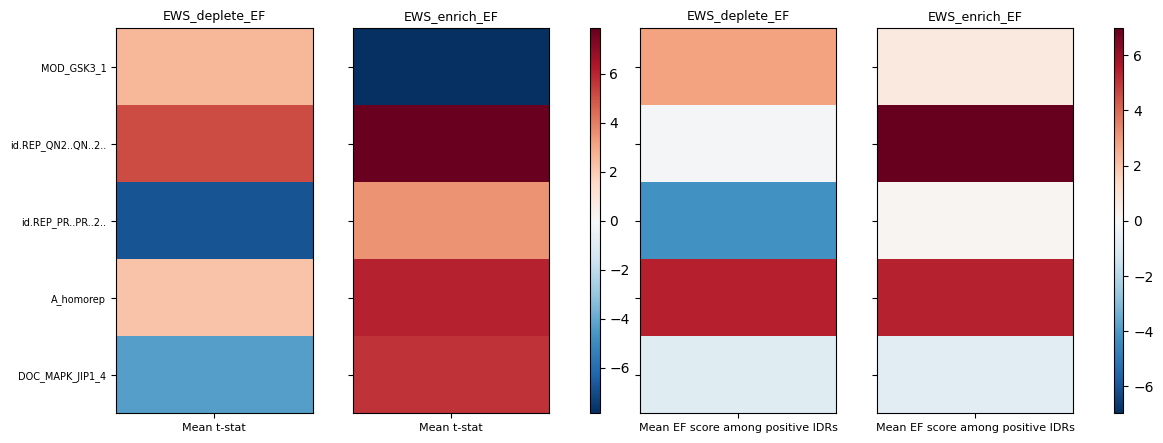

  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/EWS_paired_EF/Tstats/heatmap_tstat_es_paired_EWS_deplete_vs_enrich.png


/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(base_cmap).copy()


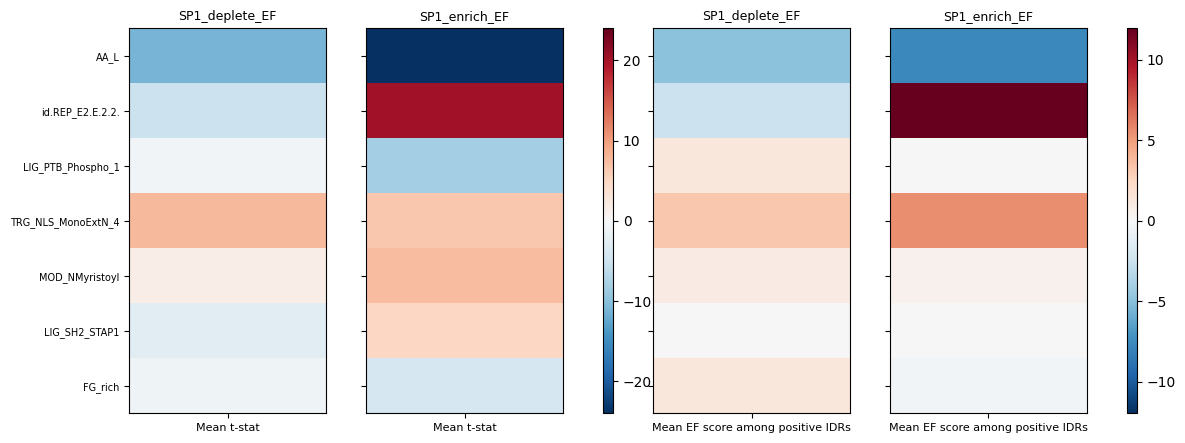

  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/SP1_paired_EF/Tstats/heatmap_tstat_es_paired_SP1_deplete_vs_enrich.png


/var/folders/ny/95qs3f2d26n4chd8xr9sxm400000gn/T/ipykernel_46759/2949335108.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(base_cmap).copy()


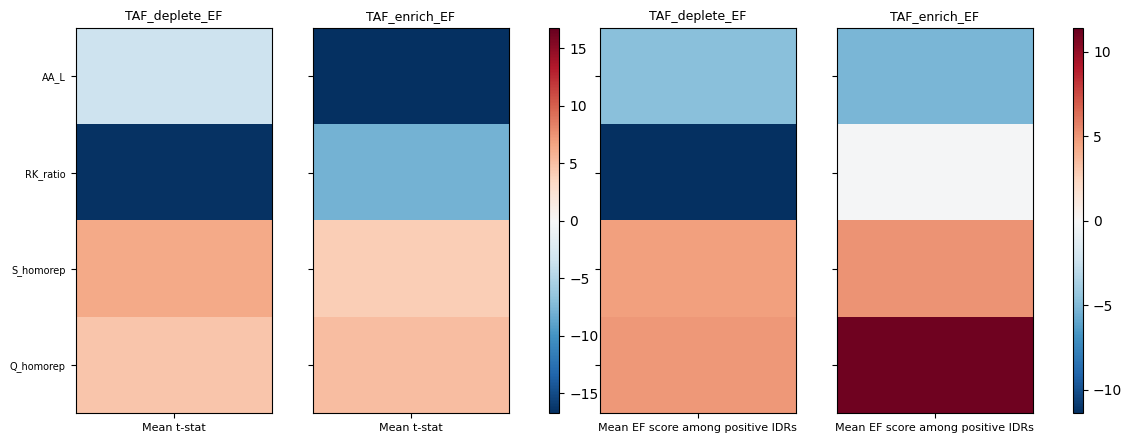

  saved → /Users/anastasy/Documents/Lab/projects/Shasha_FAIDR/FAIDR_output/TAF_paired_EF/Tstats/heatmap_tstat_es_paired_TAF_deplete_vs_enrich.png

--- Step 4c outputs ---


,bait,n_features_intersection,n_idr_above_threshold_deplete,n_idr_above_threshold_enrich,summary_table,heatmap_png
0,EWS,5,231,284,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...
1,SP1,7,383,238,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...
2,TAF,4,231,210,/Users/anastasy/Documents/Lab/projects/Shasha_...,/Users/anastasy/Documents/Lab/projects/Shasha_...


In [37]:
MEAN_EF_POS_COL = "mean_ef_score_positive_idrs"
MEAN_EF_POS_LABEL = "Mean EF score among positive IDRs"

_human_es_cache: pd.DataFrame | None = None
_tstat_to_es_cache: dict[str, dict[str, str]] = {}


def load_human_es_matrix() -> pd.DataFrame:
    global _human_es_cache
    if _human_es_cache is None:
        df = pd.read_csv(EF_PATH, sep="\t")
        df = df[df["idr_name"].notna() & df["idr_name"].astype(str).str.len().gt(0)]
        feature_cols = [c for c in df.columns if c not in ("idr_name", "NAME")]
        df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
        _human_es_cache = df
    return _human_es_cache


def build_tstat_to_es_map(tstats_dir: Path) -> dict[str, str]:
    key = str(tstats_dir.resolve())
    if key not in _tstat_to_es_cache:
        rep_path = sorted(tstats_dir.glob(TSTATS_GLOB))[0]
        tstats_feats = pd.read_csv(rep_path, sep="\t")["feature"].astype(str).tolist()
        es_cols = [c for c in load_human_es_matrix().columns if c not in ("idr_name", "NAME")]
        tstats_feats = [f for f in tstats_feats if f != "(Intercept)"]
        if len(tstats_feats) != len(es_cols):
            raise ValueError(f"Feature count mismatch: Tstats={len(tstats_feats)}, HUMAN_ES={len(es_cols)}")
        _tstat_to_es_cache[key] = dict(zip(tstats_feats, es_cols))
    return _tstat_to_es_cache[key]


def parse_ef_run(run_name: str) -> tuple[str, str]:
    """EWS_deplete_EF -> ('EWS', 'deplete')."""
    base = run_name.removesuffix("_EF")
    sample, condition = base.rsplit("_", 1)
    return sample, condition


def above_threshold_path(run_name: str) -> Path:
    sample, condition = parse_ef_run(run_name)
    return FAIDR_ROOT / run_name / f"above_threshold_{sample}_{condition}"


def load_above_threshold_idrs(run_name: str) -> set[str]:
    path = above_threshold_path(run_name)
    if not path.exists():
        raise FileNotFoundError(f"Missing {path} — run Step 2 (above_threshold) first.")
    df = pd.read_csv(path, sep="\t")
    return set(df["idr_name"].astype(str))


def intersect_summaries_for_pair(
    left: pd.DataFrame, right: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """Features passing Step 4 filters in both runs; sorted by max |mean t-stat|."""
    left_set = set(left["feature"].astype(str))
    right_set = set(right["feature"].astype(str))

    def abs_mean(f: str, summary: pd.DataFrame) -> float:
        v = summary.loc[summary["feature"].astype(str) == f, "mean_t_stat"].iloc[0]
        return float(abs(v)) if pd.notna(v) else 0.0

    features = sorted(
        left_set & right_set,
        key=lambda f: (-max(abs_mean(f, left), abs_mean(f, right)), f),
    )
    idx = pd.Index(features, name="feature")

    def reindex(summary: pd.DataFrame) -> pd.DataFrame:
        return summary.set_index("feature").reindex(idx).reset_index()

    return reindex(left), reindex(right), features


def mean_es_over_above_threshold_idrs(
    features: list[str],
    run_name: str,
    tstat_to_es: dict[str, str],
) -> pd.DataFrame:
    """Mean HUMAN_ES per feature over IDRs in above_threshold_<sample>_<condition>."""
    human_es = load_human_es_matrix()
    idr_set = load_above_threshold_idrs(run_name)
    sub = human_es[human_es["idr_name"].astype(str).isin(idr_set)]
    at_path = above_threshold_path(run_name)

    rows = []
    for feat in features:
        es_col = tstat_to_es.get(feat)
        if es_col is None or es_col not in human_es.columns:
            mean_val = np.nan
        elif sub.empty:
            mean_val = np.nan
        else:
            mean_val = float(sub[es_col].mean())
        rows.append({
            "feature": feat,
            MEAN_EF_POS_COL: mean_val,
            "es_column": es_col,
            "n_idr_above_threshold": int(len(idr_set)),
            "above_threshold_file": str(at_path),
        })
    return pd.DataFrame(rows)


def plot_paired_tstat_and_es_heatmap(
    summary_dep: pd.DataFrame,
    summary_enr: pd.DataFrame,
    es_dep: pd.DataFrame,
    es_enr: pd.DataFrame,
    deplete_run: str,
    enrich_run: str,
    bait: str,
    save_path: Path,
):
    left_a, right_a, features = intersect_summaries_for_pair(summary_dep, summary_enr)
    if not features:
        print(f"{bait}: no features in intersection — skip")
        return

    es_dep_a = es_dep.set_index("feature").reindex(features).reset_index()
    es_enr_a = es_enr.set_index("feature").reindex(features).reset_index()

    n_rows = len(features)
    fig_h = max(5, 0.22 * n_rows)
    fig = plt.figure(figsize=(13, fig_h))
    gs = fig.add_gridspec(1, 6, width_ratios=[1, 1, 0.05, 1, 1, 0.05], wspace=0.3)
    ax_td = fig.add_subplot(gs[0, 0])
    ax_te = fig.add_subplot(gs[0, 1])
    cax_t = fig.add_subplot(gs[0, 2])
    ax_ed = fig.add_subplot(gs[0, 3])
    ax_ee = fig.add_subplot(gs[0, 4])
    cax_e = fig.add_subplot(gs[0, 5])

    ylabels = [f if len(f) <= 28 else f[:25] + "..." for f in features]
    heatmap_cmap = _masked_cmap("RdBu_r")

    tstat_vals = np.concatenate([
        left_a["mean_t_stat"].to_numpy(dtype=float),
        right_a["mean_t_stat"].to_numpy(dtype=float),
    ])
    tstat_vmax = float(np.nanmax(np.abs(tstat_vals))) if tstat_vals.size else 1.0
    tstat_norm = TwoSlopeNorm(vmin=-tstat_vmax, vcenter=0, vmax=tstat_vmax) if tstat_vmax > 0 else None

    es_vals = np.concatenate([
        es_dep_a[MEAN_EF_POS_COL].to_numpy(dtype=float),
        es_enr_a[MEAN_EF_POS_COL].to_numpy(dtype=float),
    ])
    es_valid = es_vals[~np.isnan(es_vals)]
    es_vmax = float(np.nanmax(np.abs(es_valid))) if es_valid.size else 1.0
    es_norm = TwoSlopeNorm(vmin=-es_vmax, vcenter=0, vmax=es_vmax) if es_vmax > 0 else None

    tstat_panels = [
        (ax_td, left_a, deplete_run),
        (ax_te, right_a, enrich_run),
    ]
    es_panels = [
        (ax_ed, es_dep_a, deplete_run),
        (ax_ee, es_enr_a, enrich_run),
    ]

    im_tstat = None
    for ax, summary, run_name in tstat_panels:
        values = summary["mean_t_stat"].to_numpy(dtype=float).reshape(-1, 1)
        im_tstat = ax.imshow(values, aspect="auto", cmap=heatmap_cmap, norm=tstat_norm)
        ax.set_title(f"{run_name}", fontsize=9)
        ax.set_xticks([0])
        ax.set_xticklabels(["Mean t-stat"], fontsize=8)
        ax.set_yticks(range(n_rows))
        ax.set_yticklabels(ylabels if ax is ax_td else [], fontsize=7)

    im_es = None
    for ax, summary, run_name in es_panels:
        values = summary[MEAN_EF_POS_COL].to_numpy(dtype=float).reshape(-1, 1)
        masked = np.ma.masked_invalid(values)
        im_es = ax.imshow(masked, aspect="auto", cmap=heatmap_cmap, norm=es_norm)
        ax.set_title(f"{run_name}", fontsize=9)
        ax.set_xticks([0])
        ax.set_xticklabels([MEAN_EF_POS_LABEL], fontsize=8)
        ax.set_yticks(range(n_rows))
        ax.set_yticklabels([], fontsize=7)

    fig.colorbar(im_tstat, cax=cax_t)
    fig.colorbar(im_es, cax=cax_e, label=MEAN_EF_POS_LABEL)

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  saved → {save_path}")


step4c_rows = []

for bait, deplete_run, enrich_run in BAIT_PAIRS:
    deplete_dir = FAIDR_ROOT / deplete_run
    enrich_dir = FAIDR_ROOT / enrich_run

    mat_dep, n_reps = load_tstats_matrix(deplete_dir / "Tstats")
    mat_enr, _ = load_tstats_matrix(enrich_dir / "Tstats")
    summary_dep = summarize_filtered_tstats(mat_dep, n_reps)
    summary_enr = summarize_filtered_tstats(mat_enr, n_reps)

    _, _, features = intersect_summaries_for_pair(summary_dep, summary_enr)
    if not features:
        print(f"\n{bait}: no features in deplete ∩ enrich after Step 4 filters — skip")
        continue

    map_dep = build_tstat_to_es_map(deplete_dir / "Tstats")
    map_enr = build_tstat_to_es_map(enrich_dir / "Tstats")

    es_dep = mean_es_over_above_threshold_idrs(features, deplete_run, map_dep)
    es_enr = mean_es_over_above_threshold_idrs(features, enrich_run, map_enr)

    out_dir = FAIDR_ROOT / f"{bait}_paired_EF" / "Tstats"
    out_dir.mkdir(parents=True, exist_ok=True)

    combined_dep = summary_dep.set_index("feature").reindex(features).reset_index()
    combined_enr = summary_enr.set_index("feature").reindex(features).reset_index()
    table_path = out_dir / f"tstat_and_es_summary_step4c_{bait}.txt"
    pd.concat(
        [
            combined_dep.assign(run=deplete_run, panel="tstat"),
            combined_enr.assign(run=enrich_run, panel="tstat"),
            es_dep.assign(run=deplete_run, panel=MEAN_EF_POS_COL),
            es_enr.assign(run=enrich_run, panel=MEAN_EF_POS_COL),
        ],
        ignore_index=True,
    ).to_csv(table_path, sep="\t", index=False)

    png_path = out_dir / f"heatmap_tstat_es_paired_{bait}_deplete_vs_enrich.png"
    plot_paired_tstat_and_es_heatmap(
        summary_dep, summary_enr, es_dep, es_enr,
        deplete_run, enrich_run, bait, png_path,
    )

    step4c_rows.append({
        "bait": bait,
        "n_features_intersection": len(features),
        "n_idr_above_threshold_deplete": int(es_dep["n_idr_above_threshold"].iloc[0]) if len(es_dep) else 0,
        "n_idr_above_threshold_enrich": int(es_enr["n_idr_above_threshold"].iloc[0]) if len(es_enr) else 0,
        "summary_table": str(table_path),
        "heatmap_png": str(png_path),
    })

print("\n--- Step 4c outputs ---")
display(pd.DataFrame(step4c_rows))